# 🌫️ PM2.5 Maroc — Comparaison Exhaustive : Modèles, Méthodes & Stratégies

Ce notebook **lit tous les fichiers produits par les notebooks 3→7** et produit une analyse comparative complète.

| Section | Contenu |
|---------|---------|
| 0 | Configuration, chemins, métriques |
| 1 | Lecture NB3 — Baselines + ML + GRU (`leaderboard_h1.csv`) |
| 2 | Lecture NB4 — Modèles tunés Optuna + Ensemble (`leaderboard_ensemble.csv`) |
| 3 | Recalcul NB5 — Stratégies Direct/Recursive/MIMO/Hybrid depuis modèles |
| 4 | Lecture NB6 — Impact features météo (modèles enrichis + `.npz`) |
| 5 | **Fig 1** Comparaison globale H+1 — barres MAE/RMSE/R² |
| 6 | **Fig 2** MAE par horizon H+1→H+24 — toutes méthodes |
| 7 | **Fig 3** Heatmap MAE (méthode × horizon) |
| 8 | **Fig 4** Avant/Après Optuna — impact du tuning |
| 9 | **Fig 5** Avant/Après features météo |
| 10 | **Fig 6** Analyse par ville (50 villes) — LGB vs CB vs Blend |
| 11 | **Fig 7** Patterns temporels (heure / mois / jour semaine) |
| 12 | **Fig 8** Feature importance LGB & CatBoost + évolution par horizon |
| 13 | **Fig 9** Pics de pollution — analyse erreurs p50→p99 |
| 14 | **Fig 10** Scatter H+1/H+6/H+12/H+24 |
| 15 | **Fig 11** Stratégies forecast — accumulation d'erreur |
| 16 | **Fig 12** Ranking final & dashboard synthèse |


## 0. Configuration

In [1]:
import warnings, gc, json, os, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Palette ────────────────────────────────────────────────────────────────────
PALETTE = {
    'B1 – Persistence':    '#95A5A6', 'B2 – Moving Avg 6h': '#BDC3C7',
    'M1 – Ridge':          '#AED6F1', 'M2 – Random Forest': '#5DADE2',
    'M3 – Extra Trees':    '#2E86C1', 'M4 – XGBoost':       '#1A5276',
    'M5 – LightGBM':       '#F39C12', 'M6 – CatBoost':      '#E67E22',
    'M7 – GRU':            '#8E44AD',
    'LGB Tuned':           '#E74C3C', 'CB Tuned':           '#C0392B',
    'Blend LGB+CB':        '#2ECC71', 'Stack Ridge':        '#1ABC9C',
    'Direct Blend':        '#27AE60', 'Recursive LGB':      '#3498DB',
    'MIMO LGB':            '#9B59B6', 'Hybrid Direct+Rec':  '#F1C40F',
    'Direct Blend V1':     '#E74C3C', 'Blend Enrichi V2':   '#27AE60',
}

def get_color(name):
    for k, c in PALETTE.items():
        if k.lower() in name.lower() or name.lower() in k.lower():
            return c
    return '#7F8C8D'

# ── Métriques ─────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(
        np.asarray(y_true, float), np.asarray(y_pred, float))))

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean(np.abs(y_pred-y_true) / ((np.abs(y_true)+np.abs(y_pred))/2 + 1e-8)) * 100)

def evaluate(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    return {'Model': name,
            'MAE':   round(float(mean_absolute_error(yt, yp)), 4),
            'RMSE':  round(rmse(yt, yp), 4),
            'SMAPE': round(smape(yt, yp), 4),
            'R2':    round(float(r2_score(yt, yp)), 4),
            'N':     int(mask.sum())}

print('✅ Config OK')


✅ Config OK


In [2]:
# ── Chemins ────────────────────────────────────────────────────────────────────
FE_DIR       = Path(r'E:\pipeline\test2\feature_engineering_outputs')
MODEL_DIR    = Path(r'E:\pipeline\test2\modeling_outputs')
ENSEMBLE_DIR = Path(r'E:\pipeline\test2\ensemble_outputs')
ENSEMBLE_ALL = Path(r'E:\pipeline\test2\ensemble_All_outputs')
RECURSIVE_DIR= Path(r'E:\pipeline\test2\recursive_outputs')
WEATHER_DIR  = Path(r'E:\pipeline\test2\weather_model_outputs')
REALTIME_DIR = Path(r'E:\pipeline\test2\realtime_api_outputs')
OUT_DIR      = Path(r'E:\pipeline\test2\comparison_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS    = list(range(1, 25))
TARGET_COLS = [f'target24_h{h}' for h in HORIZONS]
TARGET_H1   = 'target24_h1'
SEED        = 42
np.random.seed(SEED)

for name, p in [('FE_DIR', FE_DIR), ('MODEL_DIR', MODEL_DIR),
                ('ENSEMBLE_DIR', ENSEMBLE_DIR), ('RECURSIVE_DIR', RECURSIVE_DIR),
                ('WEATHER_DIR', WEATHER_DIR)]:
    print(f'  {name:<18}: {"✅" if p.exists() else "⚠️ ABSENT"} {p}')


  FE_DIR            : ✅ E:\pipeline\test2\feature_engineering_outputs
  MODEL_DIR         : ✅ E:\pipeline\test2\modeling_outputs
  ENSEMBLE_DIR      : ✅ E:\pipeline\test2\ensemble_outputs
  RECURSIVE_DIR     : ✅ E:\pipeline\test2\recursive_outputs
  WEATHER_DIR       : ✅ E:\pipeline\test2\weather_model_outputs


In [3]:
# ── Chargement dataset & split ────────────────────────────────────────────────
df = pd.read_csv(FE_DIR / 'pm25_supervised_h1_h24.csv',
                 engine='pyarrow', dtype_backend='pyarrow')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['city','datetime']).reset_index(drop=True)

with open(FE_DIR / 'safe_feature_columns.txt') as f:
    SAFE_FEATURES = [l.strip() for l in f if l.strip()]

le = LabelEncoder()
df['city_enc'] = le.fit_transform(df['city'])
FEAT_NUM = [c for c in SAFE_FEATURES if c != 'city'] + ['city_enc']
FEAT_NUM = [c for c in FEAT_NUM if c in df.columns]
FEAT_CB  = [c for c in SAFE_FEATURES if c in df.columns]
CAT_FEAT_CB = ['city'] if 'city' in FEAT_CB else []

dates     = df['datetime'].sort_values().unique()
n         = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]
df_train  = df[df['datetime'] <  train_end].copy()
df_val    = df[(df['datetime'] >= train_end) & (df['datetime'] < val_end)].copy()
df_test   = df[df['datetime'] >= val_end].copy()

# ⚠️ Convertir en numpy float32 propre (évite les ArrowExtensionArray)
def to_np(series): return np.asarray(series, dtype=np.float32)

X_tr = df_train[FEAT_NUM].astype(float).fillna(0).values.astype(np.float32)
X_va = df_val[FEAT_NUM].astype(float).fillna(0).values.astype(np.float32)
X_te = df_test[FEAT_NUM].astype(float).fillna(0).values.astype(np.float32)

print(f'Dataset : {df.shape}  |  {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Villes  : {df["city"].nunique()}  |  Features : {len(FEAT_NUM)}')
print(f'Train   : {len(df_train):,}  |  Val : {len(df_val):,}  |  Test : {len(df_test):,}')


Dataset : (1315150, 119)  |  2023-06-09 → 2026-06-08
Villes  : 50  |  Features : 66
Train   : 1,052,100  |  Val : 131,500  |  Test : 131,550


---
## 1. Lecture NB3 — Baselines, ML & GRU

In [4]:
# Lit leaderboard_h1.csv (NB3) ; sinon recalcule B1/B2/Ridge/LGB/CB
lb_h1_path = MODEL_DIR / 'leaderboard_h1.csv'

if lb_h1_path.exists():
    df_nb3 = pd.read_csv(lb_h1_path)
    print(f'✅ leaderboard_h1.csv chargé : {len(df_nb3)} modèles')
else:
    print('⚠️  leaderboard_h1.csv absent → recalcul B1/B2/Ridge/LGB/CB')
    RESULTS_3 = []
    mask_te_h1 = df_test[TARGET_H1].notna().values
    yt_h1 = to_np(df_test.loc[mask_te_h1, TARGET_H1])

    # B1 Persistence
    yp = to_np(df_test.loc[mask_te_h1, 'pm25_lag_1h'])
    RESULTS_3.append(evaluate('B1 – Persistence', yt_h1, yp))

    # B2 Moving Average 6h
    yp = to_np(df_test.loc[mask_te_h1, 'roll_mean_6h'])
    RESULTS_3.append(evaluate('B2 – Moving Avg 6h', yt_h1, yp))

    # M1 Ridge
    sc = StandardScaler()
    mask_tr = df_train[TARGET_H1].notna().values
    Xsc_tr  = sc.fit_transform(X_tr)
    Xsc_te  = sc.transform(X_te)
    rid = Ridge(alpha=10, random_state=SEED)
    rid.fit(Xsc_tr[mask_tr], to_np(df_train.loc[mask_tr, TARGET_H1]))
    RESULTS_3.append(evaluate('M1 – Ridge', yt_h1, rid.predict(Xsc_te[mask_te_h1])))

    # LGB / CatBoost depuis ensemble_dir
    for lpath in [ENSEMBLE_DIR/'models_lgb'/'lgb_h1.txt',
                  ENSEMBLE_ALL/'checkpoints'/'models_lgb'/'lgb_h1.txt']:
        if lpath.exists():
            m = lgb.Booster(model_file=str(lpath))
            RESULTS_3.append(evaluate('M5 – LightGBM', yt_h1, m.predict(X_te[mask_te_h1])))
            break
    for cpath in [ENSEMBLE_DIR/'models_cb'/'cb_h1.cbm',
                  ENSEMBLE_ALL/'checkpoints'/'models_cb'/'cb_h1.cbm']:
        if cpath.exists():
            m = CatBoostRegressor(); m.load_model(str(cpath))
            pool = Pool(df_test.loc[mask_te_h1, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
            RESULTS_3.append(evaluate('M6 – CatBoost', yt_h1, m.predict(pool)))
            break

    df_nb3 = pd.DataFrame(RESULTS_3)
    df_nb3.to_csv(MODEL_DIR / 'leaderboard_h1.csv', index=False)
    print('✅ Recalculé & sauvegardé')

display(df_nb3.sort_values('MAE').style
        .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r')
        .format({'MAE':'{:.4f}','RMSE':'{:.4f}','SMAPE':'{:.2f}','R2':'{:.4f}'}))


✅ leaderboard_h1.csv chargé : 9 modèles


,Model,MAE,RMSE,SMAPE,R2,N
0,M6 – CatBoost,0.6432,1.3594,6.61,0.9567,131550
1,M5 – LightGBM,0.6453,1.3254,6.62,0.9589,131550
2,M1 – Ridge,0.6523,1.1852,6.92,0.9671,131550
3,M4 – XGBoost,0.6619,1.4999,6.67,0.9473,131550
4,M2 – Random Forest,0.6768,1.4353,6.99,0.9518,131550
5,M3 – Extra Trees,0.8807,1.6961,9.41,0.9327,131550
6,B1 – Persistence,1.2349,2.2005,12.78,0.8867,131550
7,M7 – GRU,1.5772,3.0884,15.97,0.7765,130350
8,B2 – Moving Avg 6h,1.9337,3.3235,20.00,0.7415,131550


---
## 2. Lecture NB4 — Modèles Tunés Optuna + Ensemble (Blend & Stacking)

In [5]:
# Lit leaderboard_ensemble.csv + ensemble_summary.csv ; sinon recalcule
lb_ens_path  = ENSEMBLE_DIR / 'leaderboard_ensemble.csv'
sum_ens_path = ENSEMBLE_DIR / 'ensemble_summary.csv'

if lb_ens_path.exists():
    df_nb4_lb = pd.read_csv(lb_ens_path)
    print(f'✅ leaderboard_ensemble.csv : {len(df_nb4_lb)} lignes')
    display(df_nb4_lb.sort_values('MAE').style
            .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r')
            .format({'MAE':'{:.4f}','RMSE':'{:.4f}','SMAPE':'{:.2f}','R2':'{:.4f}'}))
else:
    print('⚠️  leaderboard_ensemble.csv absent')
    df_nb4_lb = None

if sum_ens_path.exists():
    df_nb4_sum = pd.read_csv(sum_ens_path)
    print(f'\n✅ ensemble_summary.csv :')
    display(df_nb4_sum)
else:
    df_nb4_sum = None
    print('⚠️  ensemble_summary.csv absent')


✅ leaderboard_ensemble.csv : 4 lignes


,Model,MAE,RMSE,SMAPE,R2,N
0,Blend LGB+CB,0.6396,1.3585,6.55,0.9568,131550
1,Stack Ridge,0.6403,1.3646,6.55,0.9564,131550
2,LGB Tuned,0.6437,1.3343,6.60,0.9583,131550
3,CB Tuned,0.6442,1.3987,6.60,0.9542,131550



✅ ensemble_summary.csv :


,Modèle,MAE_mean,MAE_H1,MAE_H12,MAE_H24
0,Stack Ridge,2.4800,0.6400,2.6680,3.2210
1,Blend LGB+CB,2.4810,0.6400,2.6780,3.2210
2,CB Tuné,2.4940,0.6440,2.7010,3.2240
3,LGB Tuné,2.5030,0.6440,2.6890,3.2660


In [6]:
# ── Charger tous les modèles tunés (24 horizons) ─────────────────────────────
models_lgb = {}; models_cb = {}

for h in HORIZONS:
    for d in [ENSEMBLE_ALL/'checkpoints'/'models_lgb',
              ENSEMBLE_DIR/'models_lgb', MODEL_DIR/'models_lgb']:
        p = d / f'lgb_h{h}.txt'
        if p.exists():
            models_lgb[h] = lgb.Booster(model_file=str(p)); break

    for d in [ENSEMBLE_ALL/'checkpoints'/'models_cb',
              ENSEMBLE_DIR/'models_cb', MODEL_DIR/'models_cb']:
        p = d / f'cb_h{h}.cbm'
        if p.exists():
            m = CatBoostRegressor(); m.load_model(str(p))
            models_cb[h] = m; break

print(f'LGB chargés : {len(models_lgb)}/24  |  CB chargés : {len(models_cb)}/24')

# Blend weights
blend_w = np.array([0.55, 0.45])
for p in [ENSEMBLE_DIR/'blend_weights.npy', ENSEMBLE_ALL/'blend_weights.npy']:
    if p.exists():
        blend_w = np.load(p)
        print(f'Blend weights : LGB={blend_w[0]:.3f}  CB={blend_w[1]:.3f}')
        break

# ── Évaluation sur tous les horizons ──────────────────────────────────────────
results_lgb_h, results_cb_h, results_blend_h = [], [], []

for h in HORIZONS:
    tc  = f'target24_h{h}'
    mte = df_test[tc].notna().values
    if mte.sum() == 0: continue
    yt  = to_np(df_test.loc[mte, tc])

    yp_lgb = yp_cb = None
    if h in models_lgb:
        yp_lgb = models_lgb[h].predict(X_te[mte])
        results_lgb_h.append({'Horizon':h, 'Model':'LGB Tuned',
                               'MAE': float(mean_absolute_error(yt, yp_lgb)),
                               'RMSE': rmse(yt, yp_lgb)})
    if h in models_cb:
        pool = Pool(df_test.loc[mte, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
        yp_cb = models_cb[h].predict(pool)
        results_cb_h.append({'Horizon':h, 'Model':'CB Tuned',
                              'MAE': float(mean_absolute_error(yt, yp_cb)),
                              'RMSE': rmse(yt, yp_cb)})
    if yp_lgb is not None and yp_cb is not None:
        yp_bl = blend_w[0]*yp_lgb + blend_w[1]*yp_cb
        results_blend_h.append({'Horizon':h, 'Model':'Blend LGB+CB',
                                 'MAE': float(mean_absolute_error(yt, yp_bl)),
                                 'RMSE': rmse(yt, yp_bl),
                                 '_yt': yt, '_yp': yp_bl})

df_lgb_h   = pd.DataFrame(results_lgb_h)
df_cb_h    = pd.DataFrame(results_cb_h)
df_blend_h = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                            for r in results_blend_h])
preds_blend = {r['Horizon']:(r['_yt'], r['_yp']) for r in results_blend_h}

print(f'\nMAE moyen H1-H24 :')
if len(df_lgb_h):   print(f'  LGB Tuned   : {df_lgb_h["MAE"].mean():.4f}')
if len(df_cb_h):    print(f'  CB Tuned    : {df_cb_h["MAE"].mean():.4f}')
if len(df_blend_h): print(f'  Blend LGB+CB: {df_blend_h["MAE"].mean():.4f}')


LGB chargés : 24/24  |  CB chargés : 24/24
Blend weights : LGB=0.488  CB=0.512

MAE moyen H1-H24 :
  LGB Tuned   : 2.5026
  CB Tuned    : 2.4938
  Blend LGB+CB: 2.4807


---
## 3. Recalcul NB5 — Stratégies Direct / Recursive / MIMO / Hybrid

In [7]:
# ── Charger les best params (nécessaires pour Recursive & MIMO) ──────────────
best_lgb_params = None
for p in [ENSEMBLE_DIR/'best_lgb_params.json',
          ENSEMBLE_ALL/'best_lgb_params.json']:
    if p.exists():
        with open(p) as f: best_lgb_params = json.load(f)
        print(f'✅ best_lgb_params.json chargé depuis {p.parent.name}')
        break

if best_lgb_params is None:
    # Paramètres par défaut raisonnables si absents
    best_lgb_params = {
        'objective':'regression','metric':'mae','verbosity':-1,
        'n_jobs':-1,'random_state':SEED,'num_leaves':127,'max_depth':8,
        'learning_rate':0.05,'min_child_samples':20,'subsample':0.8,
        'colsample_bytree':0.8,'reg_alpha':0.1,'reg_lambda':0.1,
    }
    print('⚠️  best_lgb_params.json absent → params par défaut utilisés')

# ── Vérifier si le strategy_summary.csv existe (NB5 déjà exécuté) ─────────────
strat_sum_path = RECURSIVE_DIR / 'final_strategy_comparison.csv'
if strat_sum_path.exists():
    df_strat_summary = pd.read_csv(strat_sum_path)
    print(f'✅ final_strategy_comparison.csv chargé')
    display(df_strat_summary)
else:
    df_strat_summary = None
    print('⚠️  Pas de strategy_summary → les stratégies seront recalculées ci-dessous')


✅ best_lgb_params.json chargé depuis ensemble_outputs
✅ final_strategy_comparison.csv chargé


,Stratégie,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend,2.4810,0.6400,2.0890,2.6780,3.2210
1,MIMO LGB,2.5500,0.6440,2.1100,2.7320,3.3750
2,Recursive LGB,4.1440,0.6440,3.0940,4.9370,5.4540
3,Hybrid Direct+Rec,4.1520,0.6400,3.1120,4.9460,5.4560


In [8]:
# ── Stratégie DIRECT : évaluation du Blend sur H1→H24 ────────────────────────
# (déjà calculé en section 2 via preds_blend)
results_direct = []
for h in HORIZONS:
    if h not in preds_blend: continue
    yt, yp = preds_blend[h]
    results_direct.append({'Strategy':'Direct Blend','Horizon':h,
                           'MAE': float(mean_absolute_error(yt, yp)),
                           'RMSE': rmse(yt, yp)})
df_direct = pd.DataFrame(results_direct)
print(f'Direct Blend — MAE moyen : {df_direct["MAE"].mean():.4f}')


Direct Blend — MAE moyen : 2.4807


In [9]:
# ── Stratégie RECURSIVE ───────────────────────────────────────────────────────
# Entrainer 1 seul modèle LGB sur H+1 et l'appliquer en boucle
print('Training modèle récursif LGB (H+1)...')

mask_tr_h1 = df_train[TARGET_H1].notna().values
mask_va_h1 = df_val[TARGET_H1].notna().values

ds_tr = lgb.Dataset(X_tr[mask_tr_h1],
                    label=to_np(df_train.loc[mask_tr_h1, TARGET_H1]), free_raw_data=False)
ds_va = lgb.Dataset(X_va[mask_va_h1],
                    label=to_np(df_val.loc[mask_va_h1, TARGET_H1]),
                    reference=ds_tr, free_raw_data=False)

model_rec = lgb.train(
    best_lgb_params, ds_tr, num_boost_round=800,
    valid_sets=[ds_va],
    callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)]
)
print(f'✅ Best iteration: {model_rec.best_iteration}')

# Index des features pour la mise à jour des lags
feat_idx = {name:i for i,name in enumerate(FEAT_NUM)}

def update_row_recursive(row, pred_buffer, step):
    """Met à jour les lags/rolling avec les prédictions passées."""
    row = row.copy()
    # Lags PM2.5
    for lag in [1,2,3,6,12,24,48,72,168,336]:
        col = f'pm25_lag_{lag}h'
        if col in feat_idx:
            buf_idx = step - lag
            if 0 <= buf_idx < len(pred_buffer):
                row[feat_idx[col]] = pred_buffer[buf_idx]
    # Rolling means
    for w in [3,6,12,24]:
        col = f'roll_mean_{w}h'
        if col in feat_idx and len(pred_buffer) >= w:
            row[feat_idx[col]] = float(np.mean(pred_buffer[-w:]))
    # Heure cyclique
    if 'hour' in feat_idx:
        new_h = int(row[feat_idx['hour']] + step) % 24
        row[feat_idx['hour']] = new_h
        if 'hour_sin' in feat_idx: row[feat_idx['hour_sin']] = np.sin(2*np.pi*new_h/24)
        if 'hour_cos' in feat_idx: row[feat_idx['hour_cos']] = np.cos(2*np.pi*new_h/24)
    return row

print('Inférence récursive par ville...')
preds_rec = {h:[] for h in HORIZONS}
trues_rec = {h:[] for h in HORIZONS}

for city, g in df_test.groupby('city'):
    g = g.sort_values('datetime').reset_index(drop=True)
    X_city = g[FEAT_NUM].astype(float).fillna(0).values.astype(np.float32)
    for idx in range(len(g)):
        if pd.isna(g.loc[idx, TARGET_H1]): continue
        base_row = X_city[idx].copy()
        buf = []
        for h in HORIZONS:
            row_h = update_row_recursive(base_row, buf, h-1) if h > 1 else base_row
            pred = float(max(0.0, model_rec.predict(row_h.reshape(1,-1))[0]))
            buf.append(pred)
            tc = f'target24_h{h}'
            if not pd.isna(g.loc[idx, tc]):
                preds_rec[h].append(pred)
                trues_rec[h].append(float(g.loc[idx, tc]))

results_rec = []
for h in HORIZONS:
    if len(preds_rec[h]) == 0: continue
    yt, yp = np.array(trues_rec[h]), np.array(preds_rec[h])
    results_rec.append({'Strategy':'Recursive LGB','Horizon':h,
                        'MAE': float(mean_absolute_error(yt,yp)),
                        'RMSE': rmse(yt,yp)})
df_recursive = pd.DataFrame(results_rec)
print(f'✅ Recursive LGB — MAE moyen : {df_recursive["MAE"].mean():.4f}')


Training modèle récursif LGB (H+1)...
✅ Best iteration: 799
Inférence récursive par ville...
✅ Recursive LGB — MAE moyen : 3.8924


In [10]:
# ── Stratégie MIMO (MultiOutput) ──────────────────────────────────────────────
from lightgbm import LGBMRegressor

print('Training MIMO LGB...')
mask_all_tr = df_train[TARGET_COLS].notna().all(axis=1).values
mask_all_te = df_test[TARGET_COLS].notna().all(axis=1).values

Y_tr = df_train.loc[mask_all_tr, TARGET_COLS].astype(float).values.astype(np.float32)
Y_te = df_test.loc[mask_all_te,  TARGET_COLS].astype(float).values.astype(np.float32)

lgb_params_clean = {k:v for k,v in best_lgb_params.items()
                    if k not in ['objective','metric','verbosity','n_jobs','random_state']}
lgb_base  = LGBMRegressor(**lgb_params_clean, n_estimators=400, n_jobs=-1,
                           random_state=SEED, verbosity=-1)
mimo_model = MultiOutputRegressor(lgb_base, n_jobs=1)
mimo_model.fit(X_tr[mask_all_tr], Y_tr)

Y_pred_mimo = np.clip(mimo_model.predict(X_te[mask_all_te]), 0, None)
results_mimo = []
for i, h in enumerate(HORIZONS):
    results_mimo.append({'Strategy':'MIMO LGB','Horizon':h,
                         'MAE': float(mean_absolute_error(Y_te[:,i], Y_pred_mimo[:,i])),
                         'RMSE': rmse(Y_te[:,i], Y_pred_mimo[:,i])})
df_mimo = pd.DataFrame(results_mimo)
print(f'✅ MIMO LGB — MAE moyen : {df_mimo["MAE"].mean():.4f}')


Training MIMO LGB...
✅ MIMO LGB — MAE moyen : 2.5372


In [11]:
# ── Stratégie HYBRID : Direct H+1, puis Recursive H+2→H+24 ──────────────────
if 1 in models_lgb and 1 in models_cb:
    print('Inférence Hybrid (Direct H+1 + Recursive H+2→H+24) par ville...')
    preds_hyb = {h:[] for h in HORIZONS}
    trues_hyb = {h:[] for h in HORIZONS}

    for city, g in df_test.groupby('city'):
        g = g.sort_values('datetime').reset_index(drop=True)
        X_city    = g[FEAT_NUM].astype(float).fillna(0).values.astype(np.float32)
        X_city_cb = g[FEAT_CB].fillna(0)
        for idx in range(len(g)):
            if pd.isna(g.loc[idx, TARGET_H1]): continue
            base_row = X_city[idx].copy()
            buf = []
            for h in HORIZONS:
                if h == 1:
                    p_lgb = models_lgb[1].predict(base_row.reshape(1,-1))[0]
                    pool  = Pool(X_city_cb.iloc[[idx]], cat_features=CAT_FEAT_CB)
                    p_cb  = models_cb[1].predict(pool)[0]
                    pred  = float(max(0.0, blend_w[0]*p_lgb + blend_w[1]*p_cb))
                else:
                    row_h = update_row_recursive(base_row, buf, h-1)
                    pred  = float(max(0.0, model_rec.predict(row_h.reshape(1,-1))[0]))
                buf.append(pred)
                tc = f'target24_h{h}'
                if not pd.isna(g.loc[idx, tc]):
                    preds_hyb[h].append(pred)
                    trues_hyb[h].append(float(g.loc[idx, tc]))

    results_hyb = []
    for h in HORIZONS:
        if len(preds_hyb[h]) == 0: continue
        yt, yp = np.array(trues_hyb[h]), np.array(preds_hyb[h])
        results_hyb.append({'Strategy':'Hybrid Direct+Rec','Horizon':h,
                            'MAE': float(mean_absolute_error(yt,yp)),
                            'RMSE': rmse(yt,yp)})
    df_hybrid = pd.DataFrame(results_hyb)
    print(f'✅ Hybrid — MAE moyen : {df_hybrid["MAE"].mean():.4f}')
else:
    df_hybrid = pd.DataFrame()
    print('⚠️  Hybrid skippé (modèles H+1 non disponibles)')

# ── Résumé stratégies ─────────────────────────────────────────────────────────
strat_dfs = [df_direct, df_recursive, df_mimo]
if len(df_hybrid): strat_dfs.append(df_hybrid)
df_all_strat = pd.concat(strat_dfs, ignore_index=True)

summary_rows = []
for strat in df_all_strat['Strategy'].unique():
    sub = df_all_strat[df_all_strat['Strategy']==strat].set_index('Horizon')
    summary_rows.append({'Strategy': strat,
                         'MAE_mean': round(sub['MAE'].mean(),4),
                         'MAE_H1':   round(sub.loc[1,'MAE'],4) if 1 in sub.index else np.nan,
                         'MAE_H6':   round(sub.loc[6,'MAE'],4) if 6 in sub.index else np.nan,
                         'MAE_H12':  round(sub.loc[12,'MAE'],4) if 12 in sub.index else np.nan,
                         'MAE_H24':  round(sub.loc[24,'MAE'],4) if 24 in sub.index else np.nan})
df_strat_summary = pd.DataFrame(summary_rows).sort_values('MAE_mean')
print('\n📊 Résumé des stratégies :')
display(df_strat_summary.style.background_gradient(
    subset=['MAE_mean','MAE_H1','MAE_H6','MAE_H12','MAE_H24'], cmap='RdYlGn_r'))
df_strat_summary.to_csv(RECURSIVE_DIR / 'strategy_summary_computed.csv', index=False)


Inférence Hybrid (Direct H+1 + Recursive H+2→H+24) par ville...
✅ Hybrid — MAE moyen : 3.8921

📊 Résumé des stratégies :


,Strategy,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend,2.480700,0.639600,2.088800,2.677600,3.221500
2,MIMO LGB,2.537200,0.643600,2.100900,2.722800,3.356800
3,Hybrid Direct+Rec,3.892100,0.639600,2.940700,4.432300,4.847100
1,Recursive LGB,3.892400,0.643200,2.940300,4.432400,4.847200


---
## 4. Lecture NB6 — Impact Features Météo (modèles enrichis)

In [12]:
# ── Charger les modèles enrichis + résultats NB6 ─────────────────────────────
models_lgb_enr = {}; models_cb_enr = {}
results_lgb_enr = []; results_cb_enr = []

# LGB enrichi
lgb_ckpt = WEATHER_DIR / 'ckpt_lgb_enriched'
lgb_res_f = lgb_ckpt / 'results.json'
if lgb_res_f.exists():
    with open(lgb_res_f) as f: results_lgb_enr = json.load(f)
    for r in results_lgb_enr:
        p = lgb_ckpt / f'lgb_enriched_h{r["Horizon"]}.txt'
        if p.exists():
            models_lgb_enr[r['Horizon']] = lgb.Booster(model_file=str(p))
    print(f'✅ LGB enrichi : {len(models_lgb_enr)}/24 horizons chargés')
else:
    # Chercher aussi dans models_lgb_enriched (sauvegarde finale NB6)
    for h in HORIZONS:
        p = WEATHER_DIR / 'models_lgb_enriched' / f'lgb_enriched_h{h}.txt'
        if p.exists():
            models_lgb_enr[h] = lgb.Booster(model_file=str(p))
    print(f'✅ LGB enrichi (final) : {len(models_lgb_enr)}/24 horizons')

# CB enrichi
cb_ckpt = WEATHER_DIR / 'ckpt_cb_enriched'
cb_res_f = cb_ckpt / 'results.json'
if cb_res_f.exists():
    with open(cb_res_f) as f: results_cb_enr = json.load(f)
    for r in results_cb_enr:
        p = cb_ckpt / f'cb_enriched_h{r["Horizon"]}.cbm'
        if p.exists():
            m = CatBoostRegressor(); m.load_model(str(p))
            models_cb_enr[r['Horizon']] = m
    print(f'✅ CB enrichi : {len(models_cb_enr)}/24 horizons chargés')
else:
    for h in HORIZONS:
        p = WEATHER_DIR / 'models_cb_enriched' / f'cb_enriched_h{h}.cbm'
        if p.exists():
            m = CatBoostRegressor(); m.load_model(str(p))
            models_cb_enr[h] = m
    print(f'✅ CB enrichi (final) : {len(models_cb_enr)}/24 horizons')

print(f'\nDisponibilité NB6 : {len(models_lgb_enr)} LGB + {len(models_cb_enr)} CB')


✅ LGB enrichi : 24/24 horizons chargés
✅ CB enrichi : 24/24 horizons chargés

Disponibilité NB6 : 24 LGB + 24 CB


In [13]:
# ── Reconstruire les features enrichies ───────────────────────────────────────
# Lire feat_enriched.json pour savoir quelles colonnes utiliser
FEAT_ENRICHED = None; FEAT_CB_ENRICHED = None
WEATHER_HORIZONS = [1,2,3,6,9,12,15,18,21,24]

feat_enr_path = WEATHER_DIR / 'feat_enriched.json'
feat_cb_enr_path = WEATHER_DIR / 'feat_cb_enriched.json'
wh_path = WEATHER_DIR / 'weather_horizons.json'

if feat_enr_path.exists():
    with open(feat_enr_path) as f: FEAT_ENRICHED = json.load(f)
    print(f'✅ feat_enriched.json : {len(FEAT_ENRICHED)} features')
if feat_cb_enr_path.exists():
    with open(feat_cb_enr_path) as f: FEAT_CB_ENRICHED = json.load(f)
if wh_path.exists():
    with open(wh_path) as f: WEATHER_HORIZONS = json.load(f)

# Construire df_enriched si features météo présentes
df_enriched = None
weather_fc_path = WEATHER_DIR / '..' / 'weather_forecast_cache' / 'df_with_weather_fc.parquet'
# Chercher aussi dans WEATHER_DIR
for wpath in [WEATHER_DIR.parent / 'weather_forecast_cache' / 'df_with_weather_fc.parquet',
              WEATHER_DIR / 'df_with_weather_fc.parquet']:
    if wpath.exists():
        df_enriched = pd.read_parquet(wpath)
        df_enriched['datetime'] = pd.to_datetime(df_enriched['datetime'])
        df_enriched = df_enriched.sort_values(['city','datetime']).reset_index(drop=True)
        df_enriched['city_enc'] = le.transform(df_enriched['city'])
        print(f'✅ df_enriched chargé : {df_enriched.shape}')
        break

if df_enriched is None:
    print('⚠️  df_with_weather_fc.parquet non trouvé')
    print('   → Construction des features météo futures depuis données historiques...')
    from tqdm import tqdm as _tqdm

    weather_base_cols = [c for c in ['temperature','humidity','wind_speed','pressure','clouds']
                         if c in df.columns]
    df_enriched = df.copy()
    for h in _tqdm(WEATHER_HORIZONS, desc='Building weather features'):
        base = df[['city','datetime'] + weather_base_cols].copy()
        base['datetime'] = base['datetime'] - pd.Timedelta(hours=h)
        rename = {c: f'{c}_fc_h{h}' for c in weather_base_cols}
        base = base.rename(columns=rename)
        df_enriched = df_enriched.merge(base, on=['city','datetime'], how='left')
    df_enriched['city_enc'] = le.transform(df_enriched['city'])
    print(f'✅ Features météo construites : {df_enriched.shape}')


✅ feat_enriched.json : 116 features
✅ df_enriched chargé : (1315150, 169)


In [14]:
# ── Évaluation modèles enrichis sur H1→H24 ───────────────────────────────────
results_enr_blend_h = []
blend_w_v2 = blend_w  # réutiliser les poids v1 par défaut
for p in [WEATHER_DIR / 'blend_weights_v2.npy']:
    if p.exists():
        blend_w_v2 = np.load(p)
        print(f'✅ blend_weights_v2 : {blend_w_v2}')
        break

if (len(models_lgb_enr) > 0 or len(models_cb_enr) > 0) and df_enriched is not None:
    # Split test enrichi
    df_test_enr = df_enriched[df_enriched['datetime'] >= val_end].copy()

    # Features enrichies disponibles dans df_test_enr
    if FEAT_ENRICHED:
        FEAT_ENR_USE = [c for c in FEAT_ENRICHED if c in df_test_enr.columns]
    else:
        fc_cols = [c for c in df_test_enr.columns
                   if any(f'{wc}_fc_h' in c for wc in ['temperature','humidity','wind_speed','pressure','clouds'])]
        FEAT_ENR_USE = FEAT_NUM + fc_cols

    X_te_enr = df_test_enr[FEAT_ENR_USE].astype(float).fillna(0).values.astype(np.float32)

    if FEAT_CB_ENRICHED:
        FEAT_CB_ENR_USE = [c for c in FEAT_CB_ENRICHED if c in df_test_enr.columns]
    else:
        FEAT_CB_ENR_USE = [c for c in FEAT_ENR_USE if c in FEAT_CB or '_fc_h' in c]
        FEAT_CB_ENR_USE = [c for c in FEAT_CB_ENR_USE if c in df_test_enr.columns]

    print(f'Features enrichies : {len(FEAT_ENR_USE)} (base: {len(FEAT_NUM)})')

    for h in HORIZONS:
        tc  = f'target24_h{h}'
        if tc not in df_test_enr.columns: continue
        mte = df_test_enr[tc].notna().values
        if mte.sum() == 0: continue
        yt  = to_np(df_test_enr.loc[mte, tc])

        yp_lgb_e = yp_cb_e = None
        if h in models_lgb_enr:
            try:
                yp_lgb_e = models_lgb_enr[h].predict(X_te_enr[mte])
            except Exception as e:
                print(f'  LGB enrichi H+{h} erreur: {e}')
        if h in models_cb_enr:
            try:
                pool_e = Pool(df_test_enr.loc[mte, FEAT_CB_ENR_USE].fillna(0), cat_features=CAT_FEAT_CB)
                yp_cb_e = models_cb_enr[h].predict(pool_e)
            except Exception as e:
                print(f'  CB enrichi H+{h} erreur: {e}')

        if yp_lgb_e is not None and yp_cb_e is not None:
            yp_bl_e = blend_w_v2[0]*yp_lgb_e + blend_w_v2[1]*yp_cb_e
        elif yp_lgb_e is not None:
            yp_bl_e = yp_lgb_e
        elif yp_cb_e is not None:
            yp_bl_e = yp_cb_e
        else:
            continue

        results_enr_blend_h.append({'Horizon':h, 'Model':'Blend Enrichi V2',
                                    'MAE': float(mean_absolute_error(yt, yp_bl_e)),
                                    'RMSE': rmse(yt, yp_bl_e)})

    df_enr_blend_h = pd.DataFrame(results_enr_blend_h)
    if len(df_enr_blend_h):
        print(f'✅ Blend V2 enrichi — MAE moyen : {df_enr_blend_h["MAE"].mean():.4f}')
else:
    df_enr_blend_h = pd.DataFrame()
    print('⚠️  Modèles enrichis non disponibles (NB6 non exécuté ou features météo absentes)')
    print('   → Sections météo afficheront uniquement les données V1')


✅ blend_weights_v2 : [0.53813709 0.46186291]
Features enrichies : 116 (base: 66)
✅ Blend V2 enrichi — MAE moyen : 2.2416


---
## 5. Construction du DataFrame consolidé (toutes méthodes × horizons)

In [15]:
# ── Consolider toutes les séries horizon par horizon ──────────────────────────
all_h_rows = []

# Persistence (recalcul sur 24 horizons)
for h in HORIZONS:
    tc  = f'target24_h{h}'
    mte = df_test[tc].notna().values
    if mte.sum() == 0: continue
    yt  = to_np(df_test.loc[mte, tc])
    yp  = to_np(df_test.loc[mte, 'pm25_lag_1h'])
    m   = ~(np.isnan(yt)|np.isnan(yp))
    if m.sum() < 5: continue
    all_h_rows.append({'Method':'B1 – Persistence','Horizon':h,'Group':'Baseline',
                       'MAE': float(mean_absolute_error(yt[m],yp[m])),
                       'RMSE': rmse(yt[m],yp[m])})

# Moving Average (H+1 seulement — constant par design)
tc = TARGET_H1; mte = df_test[tc].notna().values
yt = to_np(df_test.loc[mte,tc]); yp_ma = to_np(df_test.loc[mte,'roll_mean_6h'])
for h in HORIZONS:
    all_h_rows.append({'Method':'B2 – Moving Avg 6h','Horizon':h,'Group':'Baseline',
                       'MAE': float(mean_absolute_error(yt,yp_ma)),
                       'RMSE': rmse(yt,yp_ma)})

# LGB Tuned
for r in results_lgb_h:
    all_h_rows.append({**r, 'Method':'LGB Tuned','Group':'NB4 – Tuning'})

# CB Tuned
for r in results_cb_h:
    all_h_rows.append({**r, 'Method':'CB Tuned','Group':'NB4 – Tuning'})

# Blend LGB+CB
for r in results_blend_h:
    if not r.get('Horizon'): continue
    all_h_rows.append({'Method':'Blend LGB+CB (V1)','Horizon':r['Horizon'],
                       'Group':'NB4 – Ensemble','MAE':r['MAE'],'RMSE':r['RMSE']})

# Stratégies NB5
for df_s, gname in [(df_direct,'NB5 – Direct'),(df_recursive,'NB5 – Recursive'),
                    (df_mimo,'NB5 – MIMO')]:
    strat = df_s['Strategy'].iloc[0] if len(df_s) else 'unknown'
    for _, row in df_s.iterrows():
        all_h_rows.append({'Method':strat,'Horizon':int(row['Horizon']),
                           'Group':gname,'MAE':row['MAE'],'RMSE':row.get('RMSE',np.nan)})
if len(df_hybrid):
    for _, row in df_hybrid.iterrows():
        all_h_rows.append({'Method':'Hybrid Direct+Rec','Horizon':int(row['Horizon']),
                           'Group':'NB5 – Hybrid','MAE':row['MAE'],'RMSE':row.get('RMSE',np.nan)})

# Météo V2
for r in results_enr_blend_h:
    all_h_rows.append({'Method':'Blend Enrichi V2 (météo)','Horizon':r['Horizon'],
                       'Group':'NB6 – Météo','MAE':r['MAE'],'RMSE':r['RMSE']})

df_all_h = pd.DataFrame(all_h_rows)
methods  = sorted(df_all_h['Method'].unique())
groups   = df_all_h.groupby('Method')['Group'].first()
print(f'✅ {len(methods)} méthodes × {df_all_h["Horizon"].nunique()} horizons')
print('Méthodes disponibles :')
for m in methods: print(f'  {groups[m]:<22} {m}')


✅ 10 méthodes × 24 horizons
Méthodes disponibles :
  Baseline               B1 – Persistence
  Baseline               B2 – Moving Avg 6h
  NB6 – Météo            Blend Enrichi V2 (météo)
  NB4 – Ensemble         Blend LGB+CB (V1)
  NB4 – Tuning           CB Tuned
  NB5 – Direct           Direct Blend
  NB5 – Hybrid           Hybrid Direct+Rec
  NB4 – Tuning           LGB Tuned
  NB5 – MIMO             MIMO LGB
  NB5 – Recursive        Recursive LGB


---
## 6. Figure 1 — Comparaison Globale H+1

In [16]:
# ── Construire la table H+1 complète ──────────────────────────────────────────
rows_h1 = []

# NB3
if df_nb3 is not None:
    for _, r in df_nb3.iterrows():
        rows_h1.append({'Model':r['Model'],'Group':'NB3 – Baseline/ML',
                        'MAE':r['MAE'],'RMSE':r.get('RMSE',np.nan),
                        'SMAPE':r.get('SMAPE',np.nan),'R2':r.get('R2',np.nan)})
# NB4 H+1
for r in results_lgb_h:
    if r['Horizon']==1:
        rows_h1.append({'Model':'LGB Tuned (Optuna)','Group':'NB4',
                        'MAE':r['MAE'],'RMSE':r['RMSE'],'SMAPE':np.nan,'R2':np.nan})
for r in results_cb_h:
    if r['Horizon']==1:
        rows_h1.append({'Model':'CB Tuned (Optuna)','Group':'NB4',
                        'MAE':r['MAE'],'RMSE':r['RMSE'],'SMAPE':np.nan,'R2':np.nan})
for r in results_blend_h:
    if r.get('Horizon')==1:
        rows_h1.append({'Model':'Blend LGB+CB','Group':'NB4',
                        'MAE':r['MAE'],'RMSE':r['RMSE'],'SMAPE':np.nan,'R2':np.nan})
# NB4 stacking/leaderboard
if df_nb4_lb is not None:
    for _, r in df_nb4_lb.iterrows():
        if r.get('Model') not in [x['Model'] for x in rows_h1]:
            rows_h1.append({'Model':r['Model'],'Group':'NB4 – Ensemble',
                            'MAE':r['MAE'],'RMSE':r.get('RMSE',np.nan),
                            'SMAPE':r.get('SMAPE',np.nan),'R2':r.get('R2',np.nan)})
# NB6 V2 H+1
for r in results_enr_blend_h:
    if r['Horizon']==1:
        rows_h1.append({'Model':'Blend Enrichi V2 (météo)','Group':'NB6',
                        'MAE':r['MAE'],'RMSE':r['RMSE'],'SMAPE':np.nan,'R2':np.nan})

df_h1 = pd.DataFrame(rows_h1).drop_duplicates('Model').sort_values('MAE').reset_index(drop=True)
print(f'✅ {len(df_h1)} modèles/méthodes comparés sur H+1')

display(df_h1[['Model','Group','MAE','RMSE','SMAPE','R2']].style
        .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r')
        .format({'MAE':'{:.4f}','RMSE':'{:.4f}','SMAPE':'{:.2f}','R2':'{:.4f}'}, na_rep='—'))


✅ 16 modèles/méthodes comparés sur H+1


,Model,Group,MAE,RMSE,SMAPE,R2
0,Blend Enrichi V2 (météo),NB6,0.6377,1.3597,—,—
1,Blend LGB+CB,NB4,0.6396,1.3585,—,—
2,Stack Ridge,NB4 – Ensemble,0.6403,1.3646,6.55,0.9564
3,M6 – CatBoost,NB3 – Baseline/ML,0.6432,1.3594,6.61,0.9567
4,LGB Tuned (Optuna),NB4,0.6437,1.3343,—,—
5,LGB Tuned,NB4 – Ensemble,0.6437,1.3343,6.60,0.9583
6,CB Tuned,NB4 – Ensemble,0.6442,1.3987,6.60,0.9542
7,CB Tuned (Optuna),NB4,0.6442,1.3987,—,—
8,M5 – LightGBM,NB3 – Baseline/ML,0.6453,1.3254,6.62,0.9589
9,M1 – Ridge,NB3 – Baseline/ML,0.6523,1.1852,6.92,0.9671


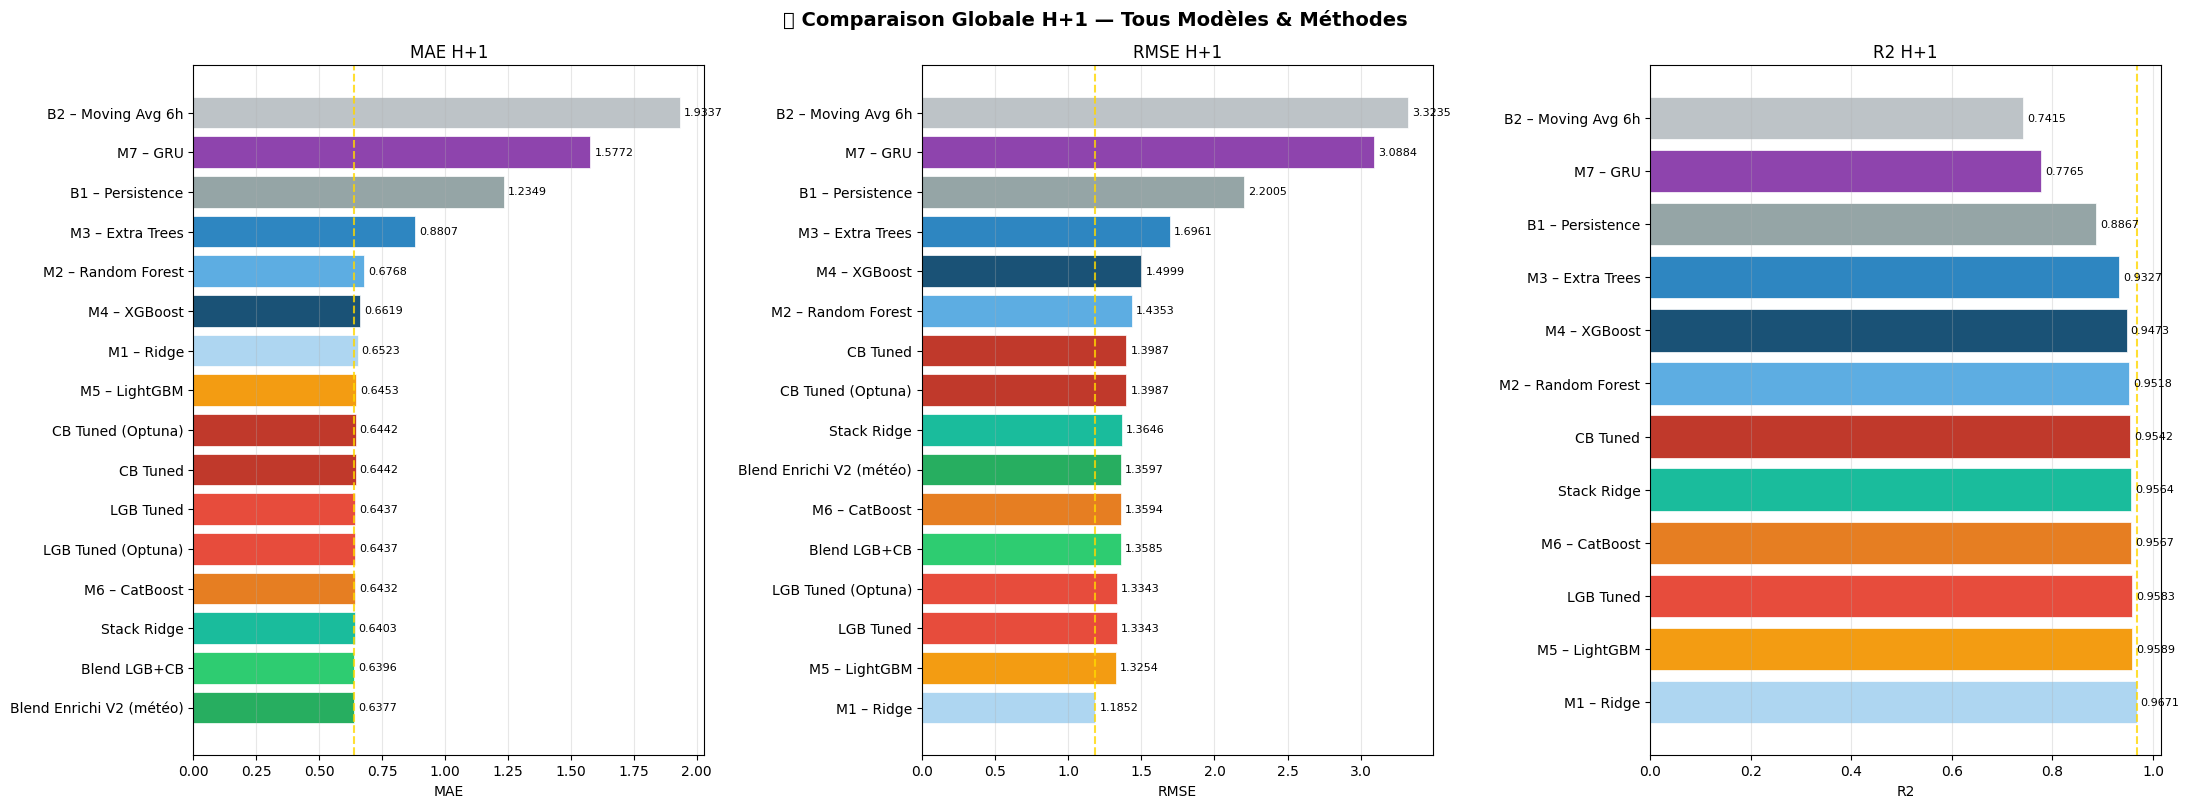

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(df_h1)*0.45+1)))

COLS = ['MAE','RMSE','R2']
CMAP = ['RdYlGn_r','RdYlGn_r','RdYlGn']
for i, (col, cmap) in enumerate(zip(COLS, CMAP)):
    sub = df_h1.dropna(subset=[col]).sort_values(col, ascending=(col!='R2'))
    if len(sub)==0:
        axes[i].text(0.5,0.5,f'{col} non disponible',ha='center',va='center',
                     transform=axes[i].transAxes); continue
    colors = [get_color(m) for m in sub['Model']]
    bars = axes[i].barh(sub['Model'], sub[col], color=colors, edgecolor='white', lw=0.5)
    axes[i].bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    best_v = sub[col].min() if col!='R2' else sub[col].max()
    axes[i].axvline(best_v, color='gold', lw=1.5, linestyle='--', alpha=0.8)
    axes[i].set(xlabel=col, title=f'{col} H+1')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('📊 Comparaison Globale H+1 — Tous Modèles & Méthodes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_global_h1.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Figure 2 — MAE par Horizon H+1→H+24

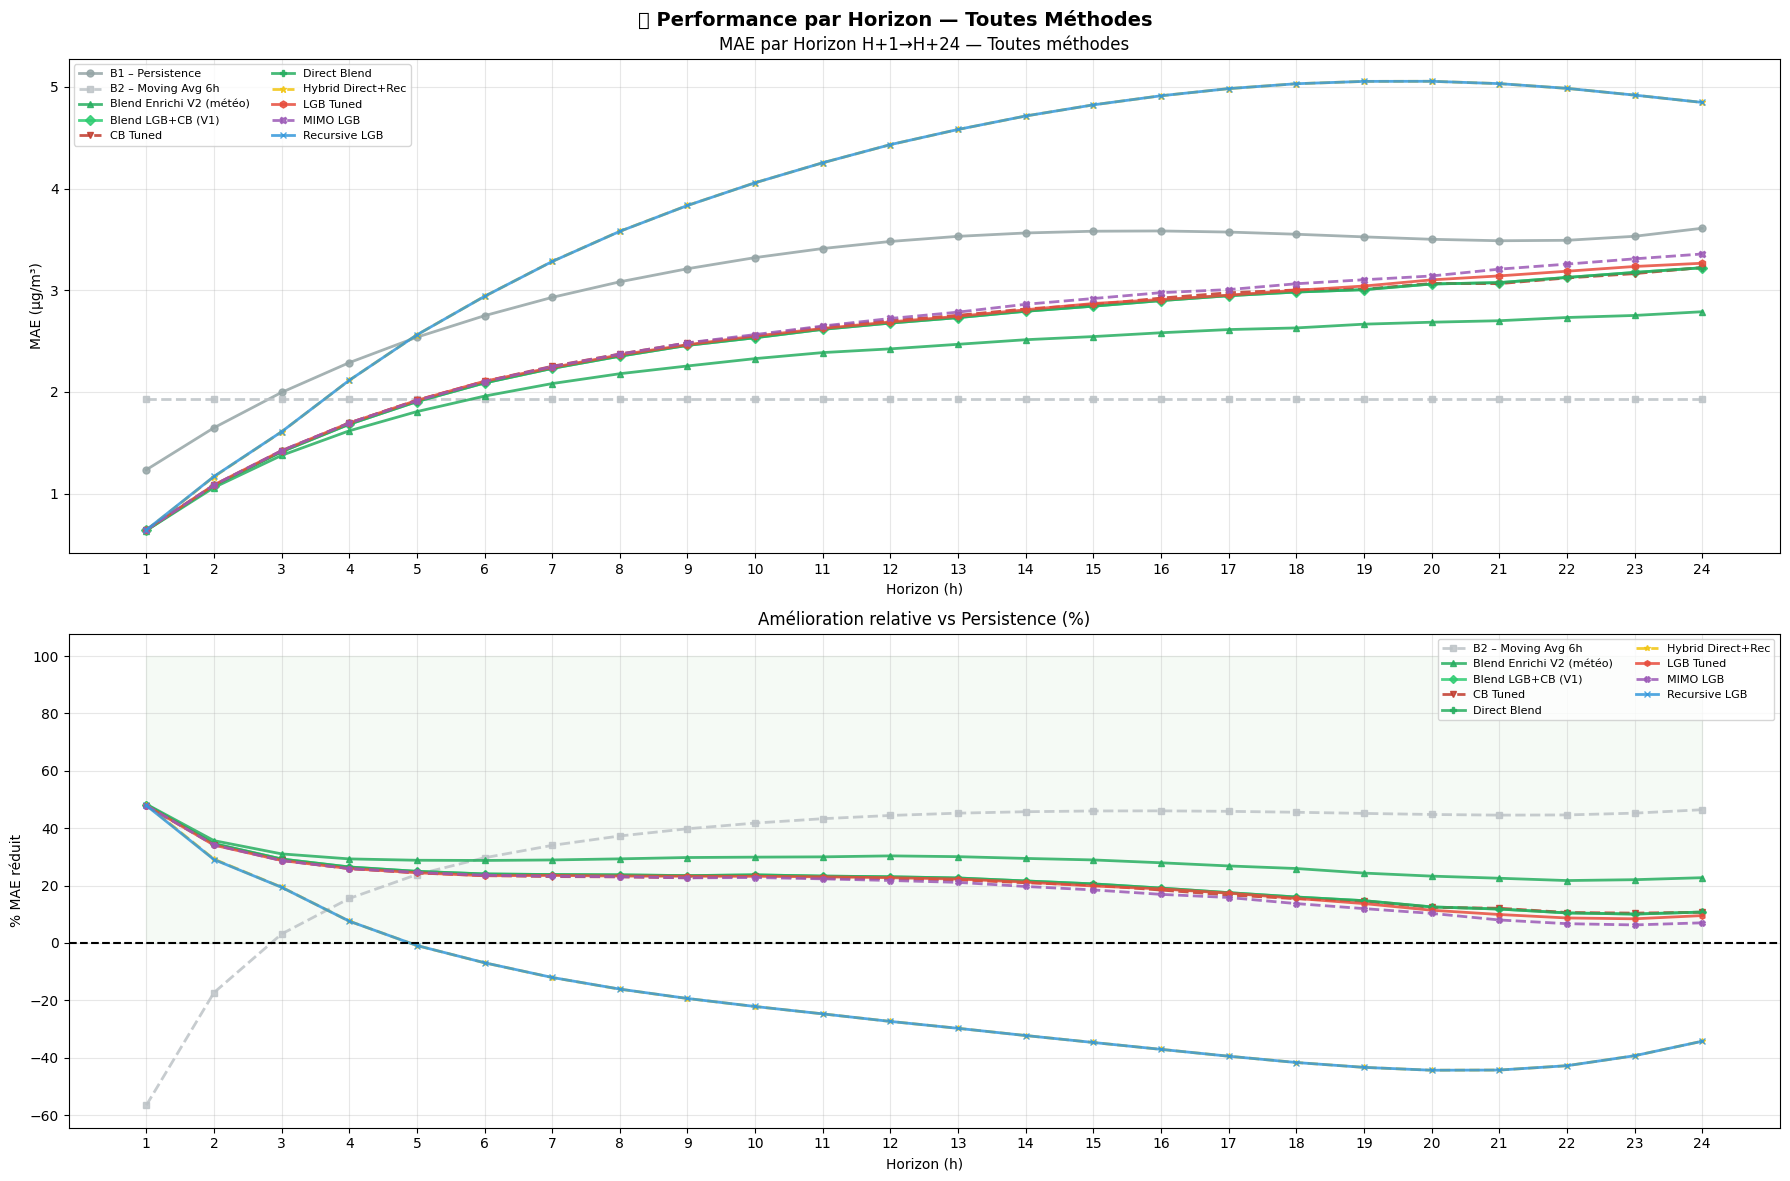

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
styles = ['o-','s--','^-','D-','v--','P-','*--','h-','X--','x-','<-','>--']

# Ax0 : Toutes les courbes
for i, method in enumerate(sorted(methods)):
    sub = df_all_h[df_all_h['Method']==method].sort_values('Horizon')
    axes[0].plot(sub['Horizon'], sub['MAE'], styles[i%len(styles)],
                 color=get_color(method), lw=2, label=method, markersize=5, alpha=0.85)

axes[0].set(title='MAE par Horizon H+1→H+24 — Toutes méthodes',
            xlabel='Horizon (h)', ylabel='MAE (µg/m³)')
axes[0].legend(fontsize=8, ncol=2, loc='upper left')
axes[0].grid(alpha=0.3); axes[0].set_xticks(HORIZONS)

# Ax1 : Amélioration % vs Persistence
pers = df_all_h[df_all_h['Method']=='B1 – Persistence'].set_index('Horizon')['MAE']
for i, method in enumerate(sorted(methods)):
    if method == 'B1 – Persistence': continue
    sub = df_all_h[df_all_h['Method']==method].sort_values('Horizon').set_index('Horizon')
    common = sub.index.intersection(pers.index)
    if len(common) < 2: continue
    impr = (pers[common] - sub.loc[common,'MAE']) / pers[common] * 100
    axes[1].plot(impr.index, impr.values, styles[i%len(styles)],
                 color=get_color(method), lw=2, label=method, markersize=4, alpha=0.85)

axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].fill_between(HORIZONS, 0, 100, alpha=0.04, color='green')
axes[1].set(title='Amélioration relative vs Persistence (%)',
            xlabel='Horizon (h)', ylabel='% MAE réduit')
axes[1].legend(fontsize=8, ncol=2, loc='upper right')
axes[1].grid(alpha=0.3); axes[1].set_xticks(HORIZONS)

plt.suptitle('📈 Performance par Horizon — Toutes Méthodes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_mae_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Figure 3 — Heatmap MAE (Méthode × Horizon)

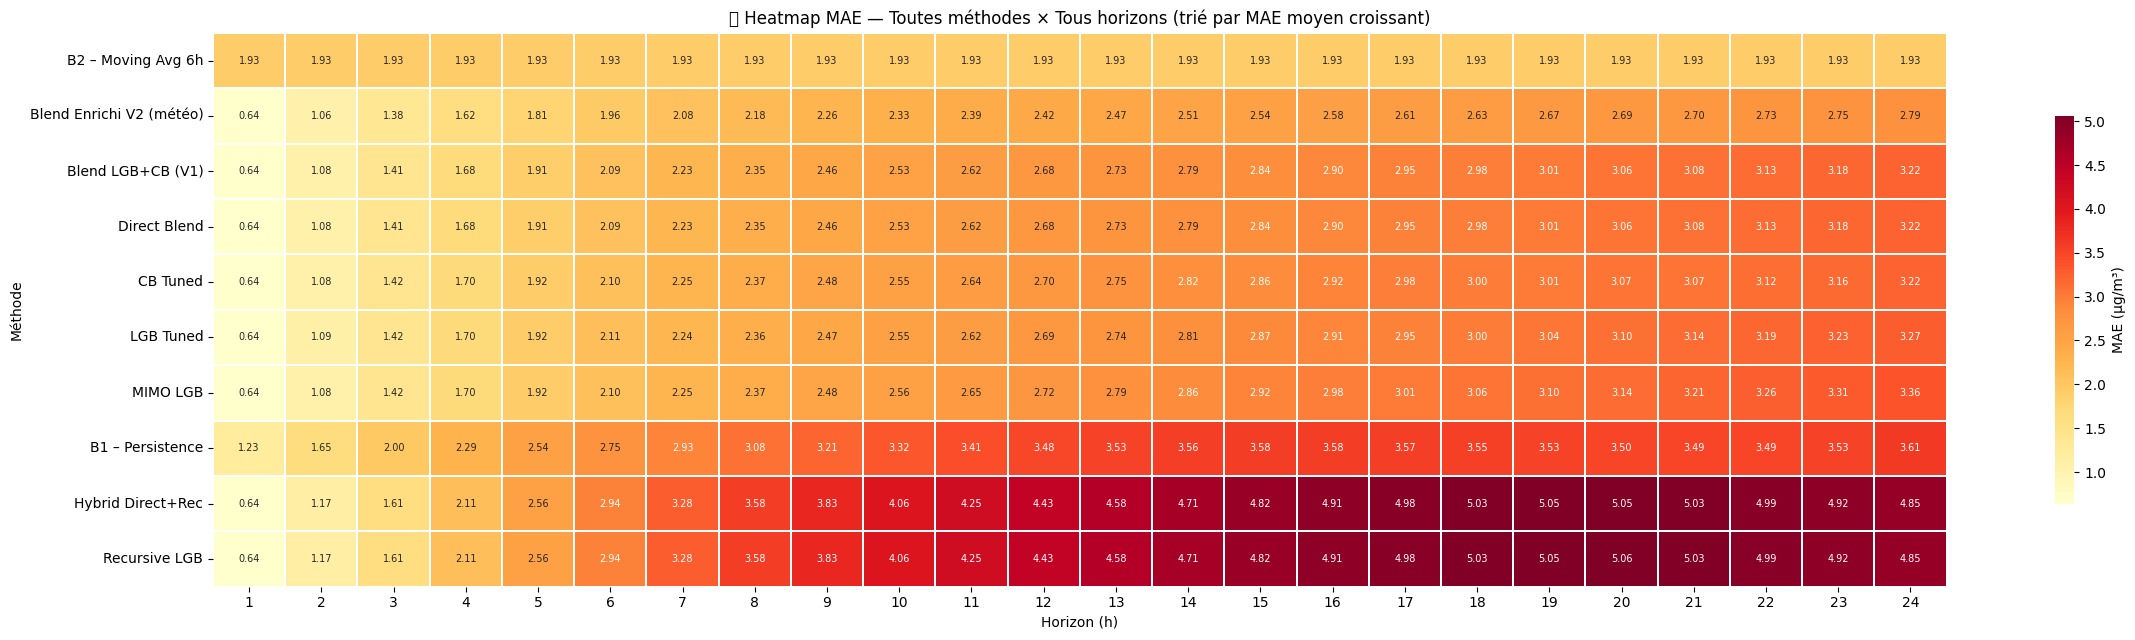


Ranking MAE moyen :
Method
B2 – Moving Avg 6h         1.9337
Blend Enrichi V2 (météo)   2.2416
Blend LGB+CB (V1)          2.4807
Direct Blend               2.4807
CB Tuned                   2.4938
LGB Tuned                  2.5026
MIMO LGB                   2.5372
B1 – Persistence           3.1009
Hybrid Direct+Rec          3.8921
Recursive LGB              3.8924


In [19]:
pivot = df_all_h.pivot_table(index='Method', columns='Horizon',
                              values='MAE', aggfunc='mean')[sorted(HORIZONS)]
pivot['_mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('_mean').drop(columns='_mean')

fig, ax = plt.subplots(figsize=(24, max(5, len(pivot)*0.55+1)))
sns.heatmap(pivot.round(2), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, annot_kws={'size':7},
            cbar_kws={'label':'MAE (µg/m³)','shrink':0.7})
ax.set(xlabel='Horizon (h)', ylabel='Méthode',
       title='🔥 Heatmap MAE — Toutes méthodes × Tous horizons (trié par MAE moyen croissant)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_heatmap_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nRanking MAE moyen :')
print(pivot.mean(axis=1).round(4).to_string())


---
## 9. Figure 4 — Avant vs Après Tuning Optuna

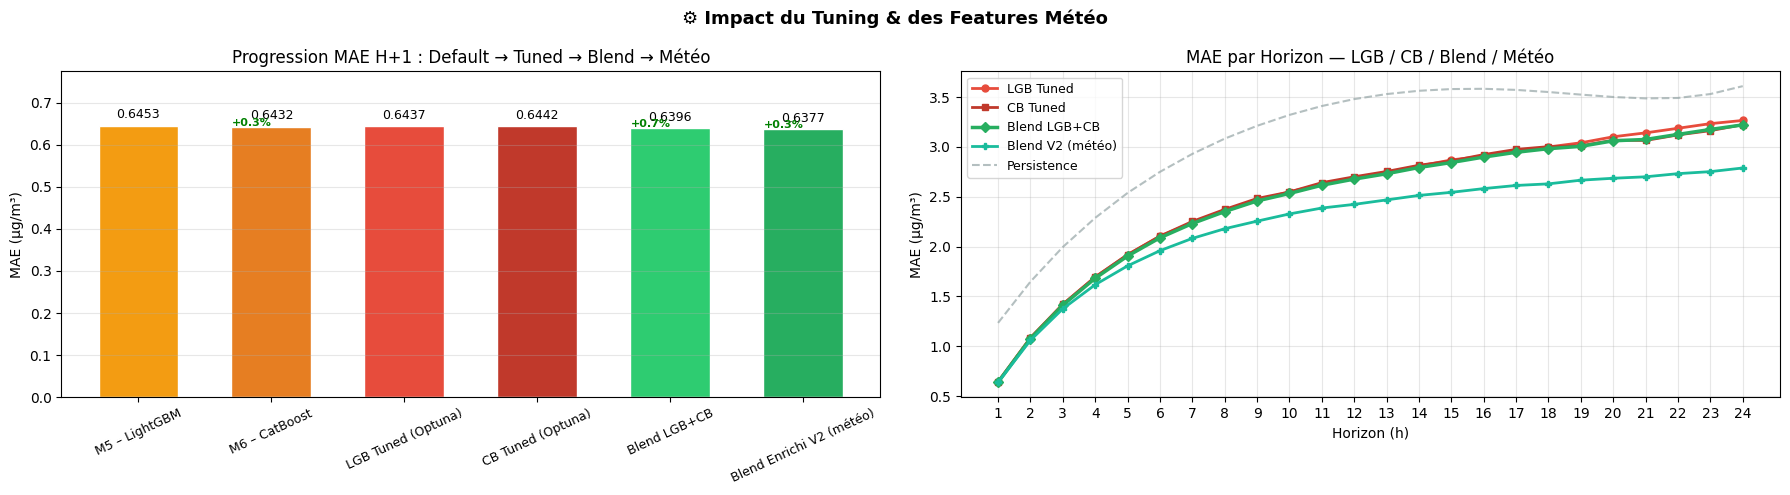

In [20]:
# Extraire MAE H+1 pour chaque étape de tuning
tuning_stages = {}
if df_nb3 is not None:
    for model in ['M5 – LightGBM','M6 – CatBoost']:
        row = df_nb3[df_nb3['Model']==model]
        if len(row): tuning_stages[model] = row['MAE'].values[0]

for r in results_lgb_h:
    if r['Horizon']==1: tuning_stages['LGB Tuned (Optuna)'] = r['MAE']
for r in results_cb_h:
    if r['Horizon']==1: tuning_stages['CB Tuned (Optuna)'] = r['MAE']
for r in results_blend_h:
    if r.get('Horizon')==1: tuning_stages['Blend LGB+CB']  = r['MAE']
for r in results_enr_blend_h:
    if r['Horizon']==1: tuning_stages['Blend Enrichi V2 (météo)'] = r['MAE']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Ax0 : Barres progression
if tuning_stages:
    names = list(tuning_stages.keys())
    maes  = [tuning_stages[k] for k in names]
    cols  = [get_color(k) for k in names]
    bars  = axes[0].bar(range(len(names)), maes, color=cols, edgecolor='white', width=0.6)
    axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    axes[0].set(xticks=range(len(names)), xticklabels=names,
                title='Progression MAE H+1 : Default → Tuned → Blend → Météo',
                ylabel='MAE (µg/m³)', ylim=(0, max(maes)*1.2))
    axes[0].tick_params(axis='x', rotation=25, labelsize=9)
    axes[0].grid(axis='y', alpha=0.3)
    # Flèches de gain
    for j in range(1, len(maes)):
        gain = (maes[j-1]-maes[j])/maes[j-1]*100
        if abs(gain) > 0.1:
            color = 'green' if gain > 0 else 'red'
            axes[0].annotate(f'{gain:+.1f}%',
                             xy=(j, maes[j]), xytext=(j-0.3, (maes[j]+maes[j-1])/2),
                             fontsize=8, color=color, fontweight='bold')

# Ax1 : Courbes H1-H24 LGB vs CB vs Blend
ax1 = axes[1]
if len(df_lgb_h): ax1.plot(df_lgb_h['Horizon'], df_lgb_h['MAE'],'o-',
                            color='#E74C3C', lw=2, label='LGB Tuned', ms=5)
if len(df_cb_h):  ax1.plot(df_cb_h['Horizon'],  df_cb_h['MAE'], 's-',
                            color='#C0392B', lw=2, label='CB Tuned', ms=5)
if len(df_blend_h): ax1.plot(df_blend_h['Horizon'], df_blend_h['MAE'],'D-',
                              color='#27AE60', lw=2.5, label='Blend LGB+CB', ms=5)
if len(df_enr_blend_h): ax1.plot(df_enr_blend_h['Horizon'], df_enr_blend_h['MAE'],'P-',
                                  color='#1ABC9C', lw=2, label='Blend V2 (météo)', ms=5)
pers_sub = df_all_h[df_all_h['Method']=='B1 – Persistence'].sort_values('Horizon')
ax1.plot(pers_sub['Horizon'], pers_sub['MAE'],'--', color='#95A5A6', lw=1.5,
         label='Persistence', alpha=0.7)
ax1.set(title='MAE par Horizon — LGB / CB / Blend / Météo',
        xlabel='Horizon (h)', ylabel='MAE (µg/m³)')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_xticks(HORIZONS)

plt.suptitle('⚙️ Impact du Tuning & des Features Météo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_tuning_meteo.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Figure 5 — Stratégies Forecast (Direct/Recursive/MIMO/Hybrid)

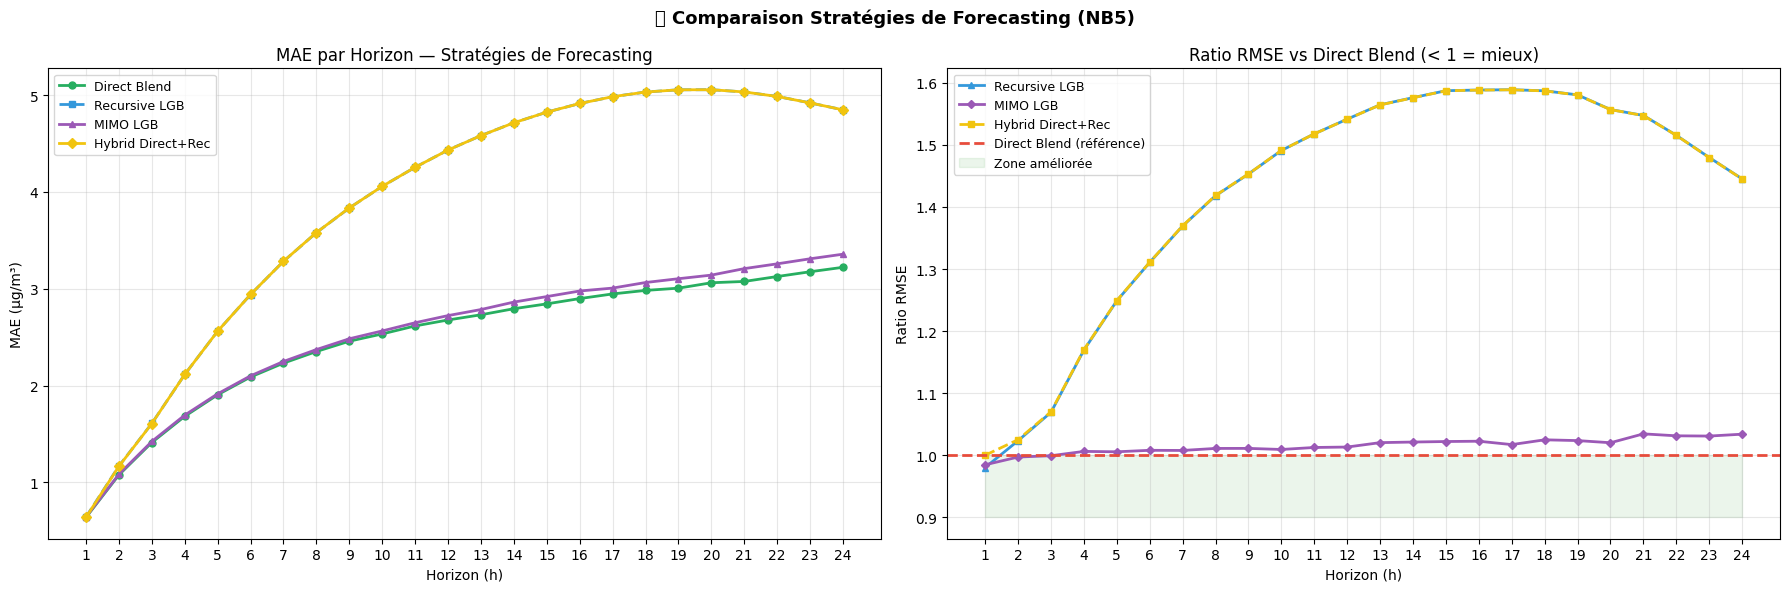

,Strategy,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend,2.480700,0.639600,2.088800,2.677600,3.221500
2,MIMO LGB,2.537200,0.643600,2.100900,2.722800,3.356800
3,Hybrid Direct+Rec,3.892100,0.639600,2.940700,4.432300,4.847100
1,Recursive LGB,3.892400,0.643200,2.940300,4.432400,4.847200


In [21]:
strat_methods = ['Direct Blend','Recursive LGB','MIMO LGB','Hybrid Direct+Rec']
strat_available = [m for m in strat_methods if m in df_all_h['Method'].values]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ax0 : Courbes MAE par horizon
for i, method in enumerate(strat_available):
    sub = df_all_h[df_all_h['Method']==method].sort_values('Horizon')
    axes[0].plot(sub['Horizon'], sub['MAE'], ['o-','s--','^-','D-'][i%4],
                 color=get_color(method), lw=2, label=method, ms=5)
axes[0].set(title='MAE par Horizon — Stratégies de Forecasting',
            xlabel='Horizon (h)', ylabel='MAE (µg/m³)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].set_xticks(HORIZONS)

# Ax1 : Ratio RMSE vs Direct Blend
direct_rmse = df_all_h[df_all_h['Method']=='Direct Blend'].set_index('Horizon')['RMSE']
for i, method in enumerate(strat_available):
    if method == 'Direct Blend': continue
    sub = df_all_h[df_all_h['Method']==method].set_index('Horizon')['RMSE']
    common = sub.index.intersection(direct_rmse.index)
    if len(common) < 2: continue
    ratio = sub[common] / direct_rmse[common]
    axes[1].plot(ratio.index, ratio.values, ['s--','^-','D-'][i%3],
                 color=get_color(method), lw=2, label=method, ms=4)

axes[1].axhline(1.0, color='#E74C3C', lw=2, linestyle='--', label='Direct Blend (référence)')
axes[1].fill_between(HORIZONS, 0.9, 1.0, alpha=0.08, color='green', label='Zone améliorée')
axes[1].set(title='Ratio RMSE vs Direct Blend (< 1 = mieux)',
            xlabel='Horizon (h)', ylabel='Ratio RMSE')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3); axes[1].set_xticks(HORIZONS)

plt.suptitle('🔄 Comparaison Stratégies de Forecasting (NB5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig5_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau résumé
if len(df_strat_summary):
    display(df_strat_summary.style.background_gradient(
        subset=['MAE_mean','MAE_H1','MAE_H6','MAE_H12','MAE_H24'], cmap='RdYlGn_r'))


---
## 11. Figure 6 — Analyse par Ville (50 villes)

In [24]:
print('Calcul MAE par ville...')
city_rows = []
# mask_h1 = df_test[TARGET_H1].notna().values

# for city in sorted(df['city'].unique()):
#     cmask = (df_test['city']==city).values & mask_h1
#     if cmask.sum() < 5: continue
#     yt = to_np(df_test.loc[cmask, TARGET_H1])

mask_h1 = df_test[TARGET_H1].notna().to_numpy(dtype=bool)

for city in sorted(df['city'].unique()):
    cmask = (df_test['city'] == city).to_numpy(dtype=bool) & mask_h1

    if np.sum(cmask) < 5:
        continue
    yt = to_np(df_test.loc[cmask, TARGET_H1])
    

    row = {'City': city,
           'N': int(cmask.sum()),
           'PM25_mean': float(df[df['city']==city]['pm2_5'].mean()),
           'PM25_std':  float(df[df['city']==city]['pm2_5'].std())}

    # Persistence
    yp = to_np(df_test.loc[cmask, 'pm25_lag_1h'])
    m  = ~(np.isnan(yt)|np.isnan(yp))
    if m.sum()>0: row['MAE_Persistence'] = float(mean_absolute_error(yt[m],yp[m]))

    # LGB Tuned
    if 1 in models_lgb:
        yp_lgb = models_lgb[1].predict(X_te[cmask])
        row['MAE_LGB'] = float(mean_absolute_error(yt, yp_lgb))

    # CB Tuned
    if 1 in models_cb:
        pool = Pool(df_test.loc[cmask, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
        yp_cb = models_cb[1].predict(pool)
        row['MAE_CB'] = float(mean_absolute_error(yt, yp_cb))

    # Blend
    if 'yp_lgb' in dir() and 'yp_cb' in dir() and 1 in models_lgb and 1 in models_cb:
        yp_bl = blend_w[0]*yp_lgb + blend_w[1]*yp_cb
        row['MAE_Blend'] = float(mean_absolute_error(yt, yp_bl))
        row['R2_Blend']  = float(r2_score(yt, yp_bl))

    city_rows.append(row)

df_city = pd.DataFrame(city_rows)
mae_col = 'MAE_Blend' if 'MAE_Blend' in df_city else 'MAE_LGB' if 'MAE_LGB' in df_city else 'MAE_Persistence'
df_city = df_city.sort_values(mae_col).reset_index(drop=True)
print(f'✅ {len(df_city)} villes  |  MAE Blend moyen : {df_city[mae_col].mean():.4f}')
display(df_city[['City','PM25_mean',mae_col,'MAE_Persistence']].head(15))


Calcul MAE par ville...
✅ 50 villes  |  MAE Blend moyen : 0.6396


,City,PM25_mean,MAE_Blend,MAE_Persistence
0,Fnidek,8.2919,0.4089,0.7500
1,Khenifra,7.4783,0.4204,0.7802
2,Al Hoceïma,7.8118,0.4281,0.7937
3,Oued Zem,7.7893,0.4407,0.8440
4,Tangier,8.7695,0.4556,0.8890
5,Al Fqih Ben Çalah,8.0372,0.4587,0.8677
6,Taza,7.8813,0.4629,0.8403
7,Ksar El Kebir,8.2879,0.4679,0.9304
8,Khouribga,8.0435,0.4685,0.9062
9,El Kelaa des Srarhna,8.5595,0.4848,0.9033


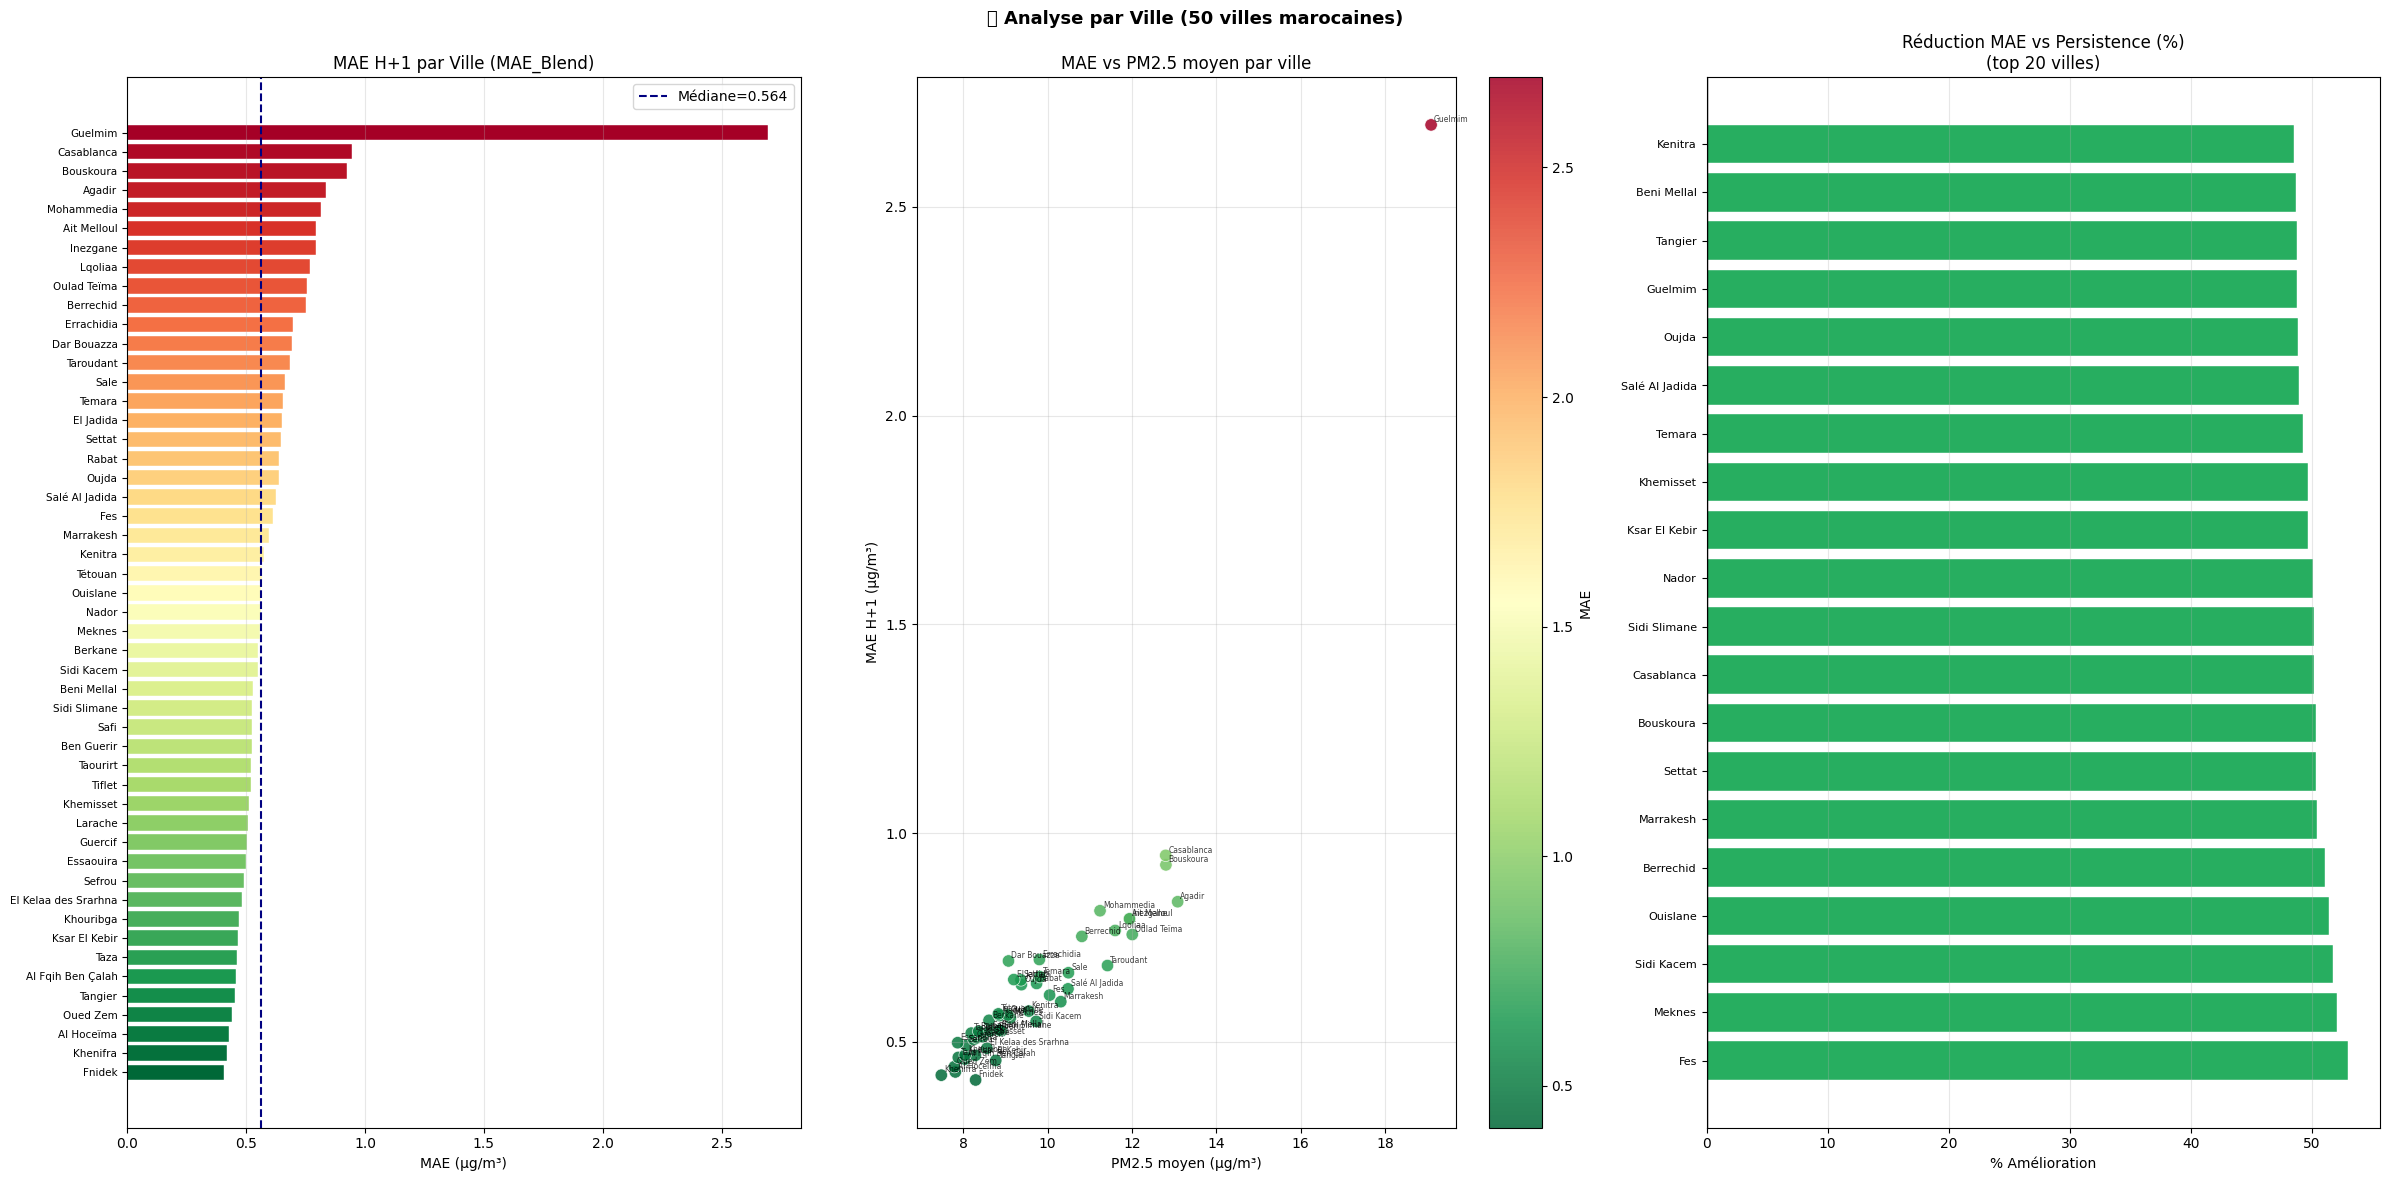

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(24, 12))

# Ax0 : Barres MAE par ville
df_cs = df_city.sort_values(mae_col)
cols_c = plt.cm.RdYlGn_r(np.linspace(0,1,len(df_cs)))
bars = axes[0].barh(df_cs['City'], df_cs[mae_col], color=cols_c, edgecolor='white', lw=0.3)
axes[0].axvline(df_cs[mae_col].median(), color='navy', lw=1.5, linestyle='--',
                label=f'Médiane={df_cs[mae_col].median():.3f}')
axes[0].set(title=f'MAE H+1 par Ville ({mae_col})', xlabel='MAE (µg/m³)')
axes[0].tick_params(axis='y', labelsize=7.5)
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

# Ax1 : Scatter MAE vs PM2.5 moyen
if 'PM25_mean' in df_city.columns:
    sc = axes[1].scatter(df_city['PM25_mean'], df_city[mae_col],
                         c=df_city[mae_col], cmap='RdYlGn_r', s=80, alpha=0.85,
                         edgecolors='white', linewidths=0.5)
    plt.colorbar(sc, ax=axes[1], label='MAE')
    for _, r in df_city.iterrows():
        axes[1].annotate(r['City'], (r['PM25_mean'], r[mae_col]),
                         fontsize=5.5, alpha=0.75, xytext=(2,2), textcoords='offset points')
    axes[1].set(title='MAE vs PM2.5 moyen par ville',
                xlabel='PM2.5 moyen (µg/m³)', ylabel='MAE H+1 (µg/m³)')
    axes[1].grid(alpha=0.3)

# Ax2 : Réduction vs Persistence (top 20 villes)
if 'MAE_Persistence' in df_city.columns:
    df_city['Gain%'] = (df_city['MAE_Persistence']-df_city[mae_col])/df_city['MAE_Persistence']*100
    df_gain = df_city.sort_values('Gain%', ascending=False).head(20)
    cols_g = ['#27AE60' if x>0 else '#E74C3C' for x in df_gain['Gain%']]
    axes[2].barh(df_gain['City'], df_gain['Gain%'], color=cols_g, edgecolor='white', lw=0.3)
    axes[2].axvline(0, color='black', lw=1)
    axes[2].set(
        title='Réduction MAE vs Persistence (%)\n(top 20 villes)',
        xlabel='% Amélioration'
    )
    axes[2].tick_params(axis='y', labelsize=8)
    axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('🏙️ Analyse par Ville (50 villes marocaines)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig6_mae_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Figure 7 — Patterns Temporels

In [27]:
if 1 in models_lgb and 1 in models_cb:
    mask_h1 = df_test[TARGET_H1].notna().values
    yp_lgb_all = models_lgb[1].predict(X_te[mask_h1])
    pool_all   = Pool(df_test.loc[mask_h1, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    yp_cb_all  = models_cb[1].predict(pool_all)
    yp_all     = blend_w[0]*yp_lgb_all + blend_w[1]*yp_cb_all

    # ⚠️ FIX ArrowExtensionArray : convertir en numpy float avant tout calcul
    df_eval = df_test[mask_h1].copy()
    df_eval['y_pred']    = yp_all
    df_eval['y_true']    = to_np(df_test.loc[mask_h1, TARGET_H1])  # numpy float32
    df_eval['abs_error'] = np.abs(df_eval['y_true'] - df_eval['y_pred'])
    df_eval['hour']      = pd.to_datetime(df_eval['datetime']).dt.hour
    df_eval['month']     = pd.to_datetime(df_eval['datetime']).dt.month
    df_eval['dow']       = pd.to_datetime(df_eval['datetime']).dt.dayofweek

    mae_hr  = df_eval.groupby('hour')['abs_error'].mean()
    mae_mo  = df_eval.groupby('month')['abs_error'].mean()
    mae_dow = df_eval.groupby('dow')['abs_error'].mean()
    print('✅ MAE temporelle calculée')


✅ MAE temporelle calculée


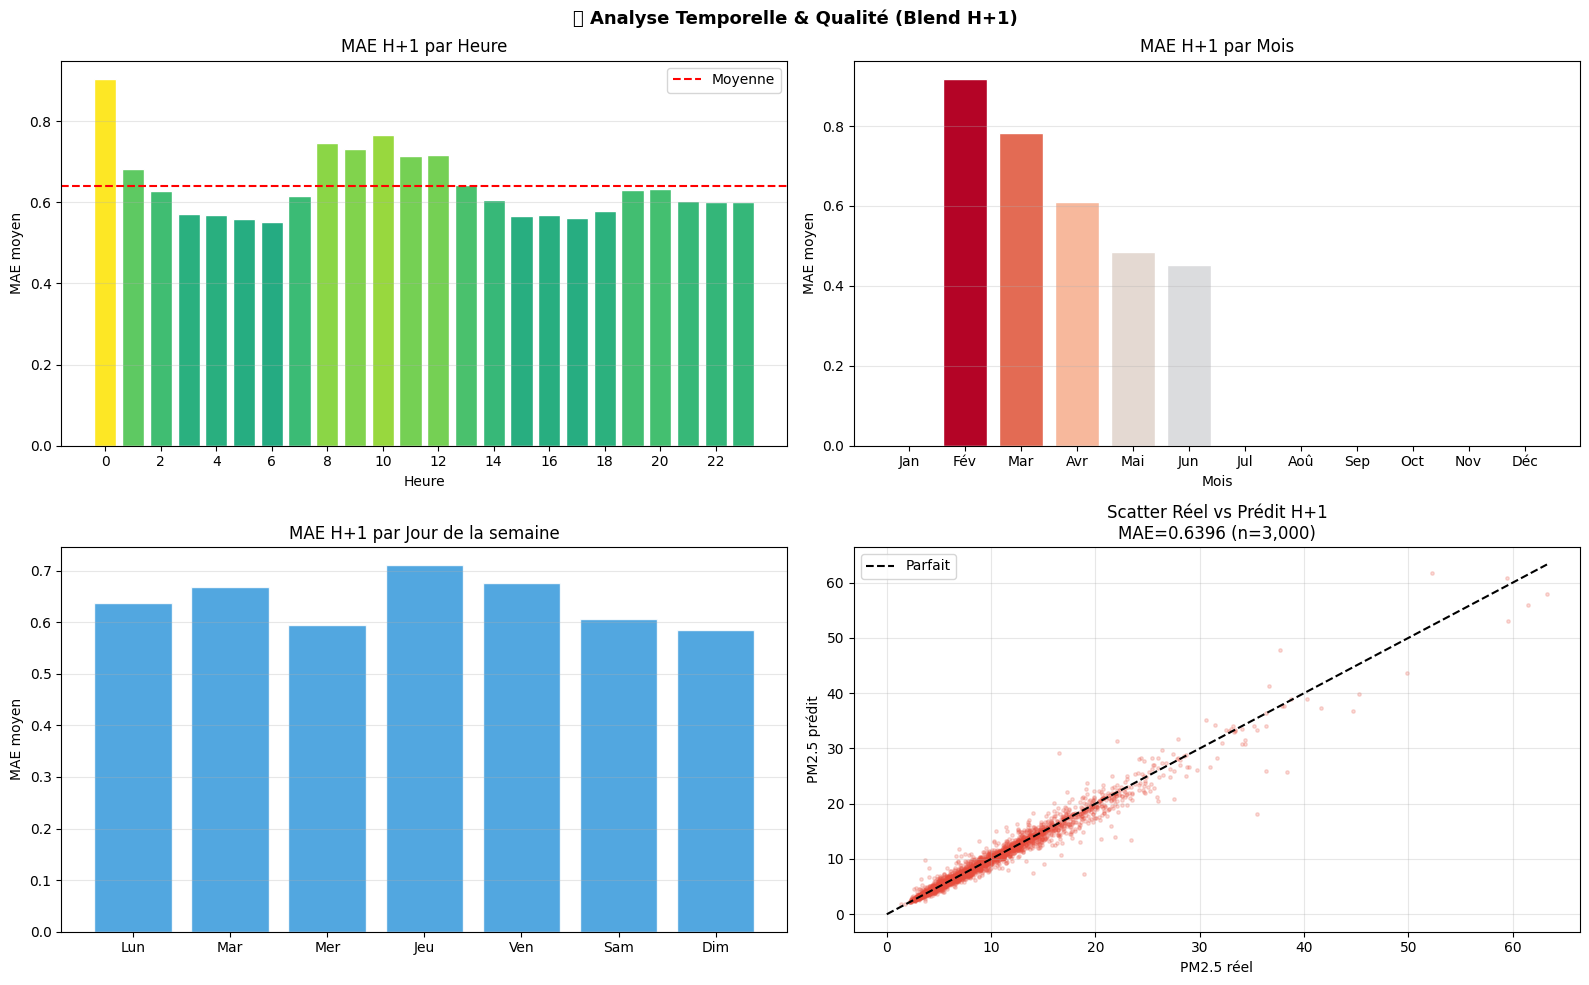

In [28]:
if 'mae_hr' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Heure
    axes[0,0].bar(mae_hr.index, mae_hr.values,
                  color=plt.cm.viridis(mae_hr.values/mae_hr.max()), edgecolor='white')
    axes[0,0].axhline(mae_hr.mean(), color='red', lw=1.5, linestyle='--', label='Moyenne')
    axes[0,0].set(title='MAE H+1 par Heure', xlabel='Heure', ylabel='MAE moyen',
                  xticks=range(0,24,2))
    axes[0,0].legend(); axes[0,0].grid(axis='y', alpha=0.3)

    # Mois
    month_names = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
    vals_mo = [mae_mo.get(m,0) for m in range(1,13)]
    axes[0,1].bar(range(1,13), vals_mo,
                  color=plt.cm.coolwarm(np.array(vals_mo)/max(vals_mo)), edgecolor='white')
    axes[0,1].set(title='MAE H+1 par Mois', xlabel='Mois', ylabel='MAE moyen',
                  xticks=range(1,13), xticklabels=month_names)
    axes[0,1].grid(axis='y', alpha=0.3)

    # Jour de la semaine
    dow_names = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
    vals_dow = [mae_dow.get(d,0) for d in range(7)]
    axes[1,0].bar(range(7), vals_dow, color='#3498DB', edgecolor='white', alpha=0.85)
    axes[1,0].set(title='MAE H+1 par Jour de la semaine',
                  xticks=range(7), xticklabels=dow_names, ylabel='MAE moyen')
    axes[1,0].grid(axis='y', alpha=0.3)

    # Scatter réel vs prédit — ⚠️ utiliser .values float pour max()
    idx_s = np.random.choice(len(df_eval), min(3000, len(df_eval)), replace=False)
    yt_s  = df_eval['y_true'].values.astype(float)[idx_s]   # ← fix ArrowExtensionArray
    yp_s  = df_eval['y_pred'].values.astype(float)[idx_s]
    lim   = max(float(yt_s.max()), float(yp_s.max()))
    sc    = axes[1,1].scatter(yt_s, yp_s, alpha=0.2, s=6, c='#E74C3C')
    axes[1,1].plot([0,lim],[0,lim],'k--', lw=1.5, label='Parfait')
    mae_glob = float(mean_absolute_error(df_eval['y_true'].values.astype(float),
                                         df_eval['y_pred'].values.astype(float)))
    axes[1,1].set(title=f'Scatter Réel vs Prédit H+1\nMAE={mae_glob:.4f} (n={len(idx_s):,})',
                  xlabel='PM2.5 réel', ylabel='PM2.5 prédit')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    plt.suptitle('🕐 Analyse Temporelle & Qualité (Blend H+1)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig7_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Figure 7 ignorée (modèles non disponibles)')


---
## 13. Figure 8 — Feature Importance (LGB & CatBoost)

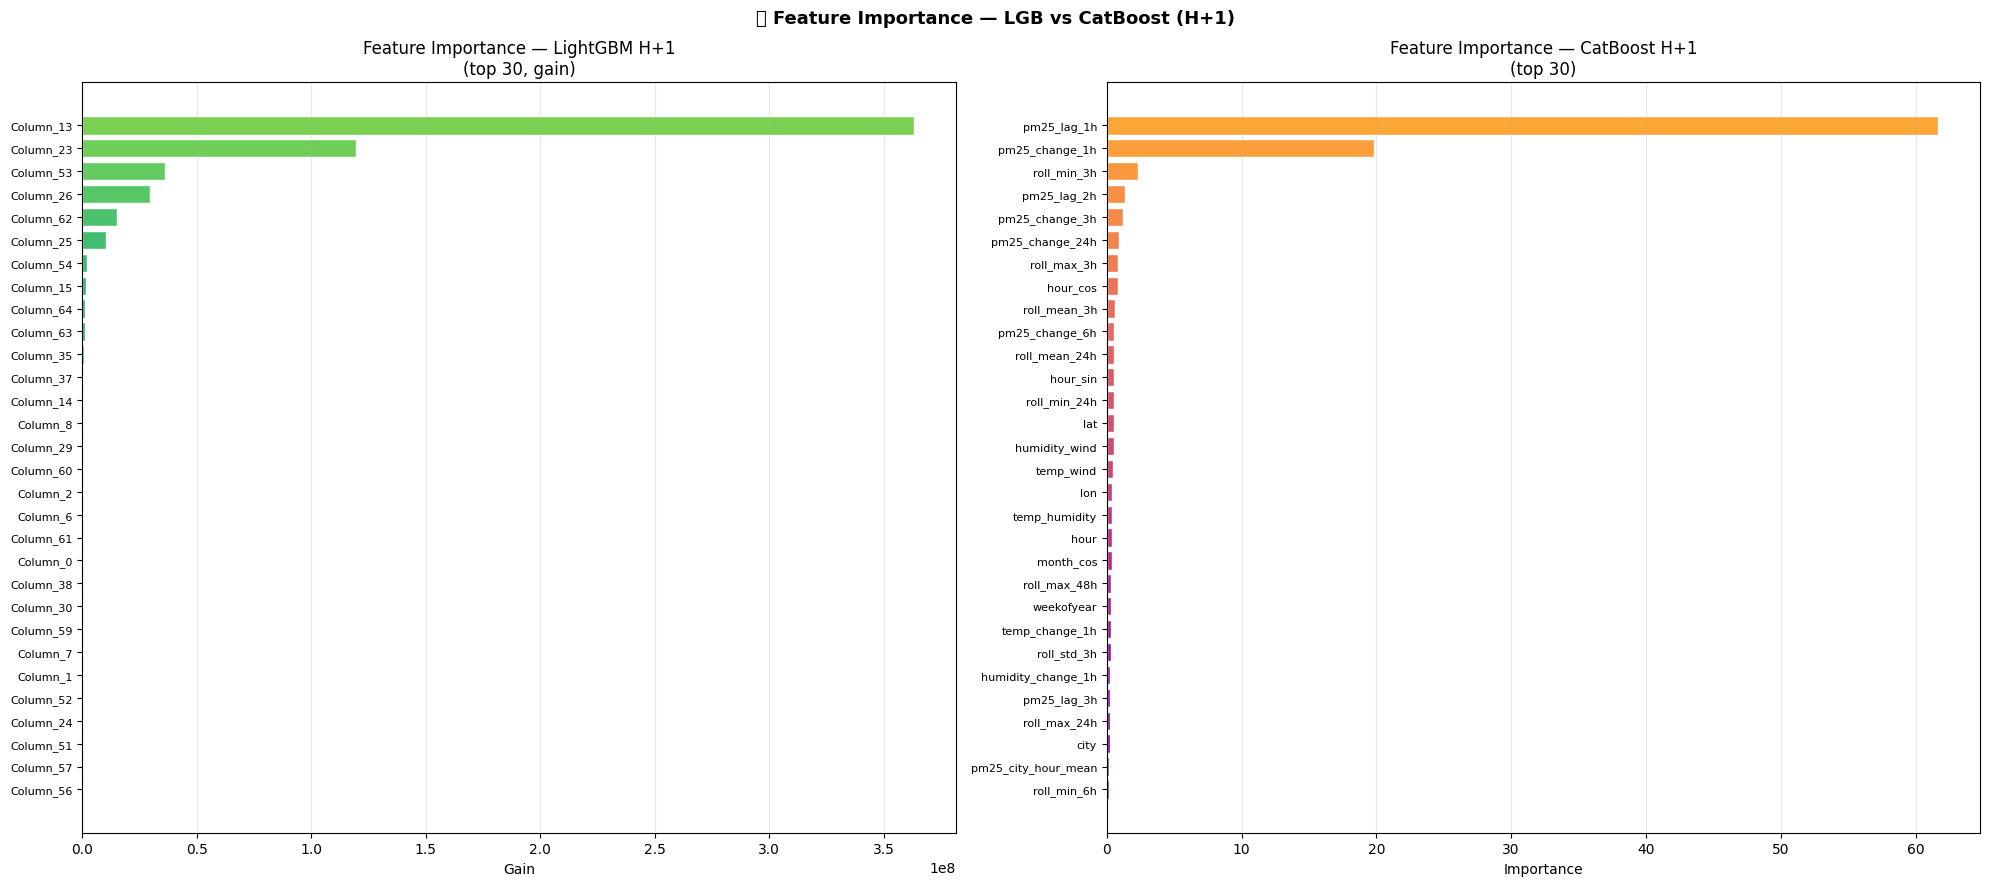

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

if 1 in models_lgb:
    m = models_lgb[1]
    imp = pd.Series(m.feature_importance('gain'), index=m.feature_name()).sort_values(ascending=False).head(30)
    colors_i = plt.cm.viridis(np.linspace(0.8,0.2,len(imp)))
    axes[0].barh(imp.index[::-1], imp.values[::-1], color=colors_i[::-1], edgecolor='white')
    axes[0].set(title='Feature Importance — LightGBM H+1\n(top 30, gain)', xlabel='Gain')
    axes[0].tick_params(axis='y', labelsize=8); axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5,0.5,'LGB non disponible',ha='center',va='center',transform=axes[0].transAxes)

if 1 in models_cb:
    m = models_cb[1]
    try:    fi_idx = m.feature_names_
    except: fi_idx = FEAT_CB[:len(m.get_feature_importance())]
    imp_cb = pd.Series(m.get_feature_importance(), index=fi_idx).sort_values(ascending=False).head(30)
    colors_i2 = plt.cm.plasma(np.linspace(0.8,0.2,len(imp_cb)))
    axes[1].barh(imp_cb.index[::-1], imp_cb.values[::-1], color=colors_i2[::-1], edgecolor='white')
    axes[1].set(title='Feature Importance — CatBoost H+1\n(top 30)', xlabel='Importance')
    axes[1].tick_params(axis='y', labelsize=8); axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5,0.5,'CB non disponible',ha='center',va='center',transform=axes[1].transAxes)

plt.suptitle('🔍 Feature Importance — LGB vs CatBoost (H+1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


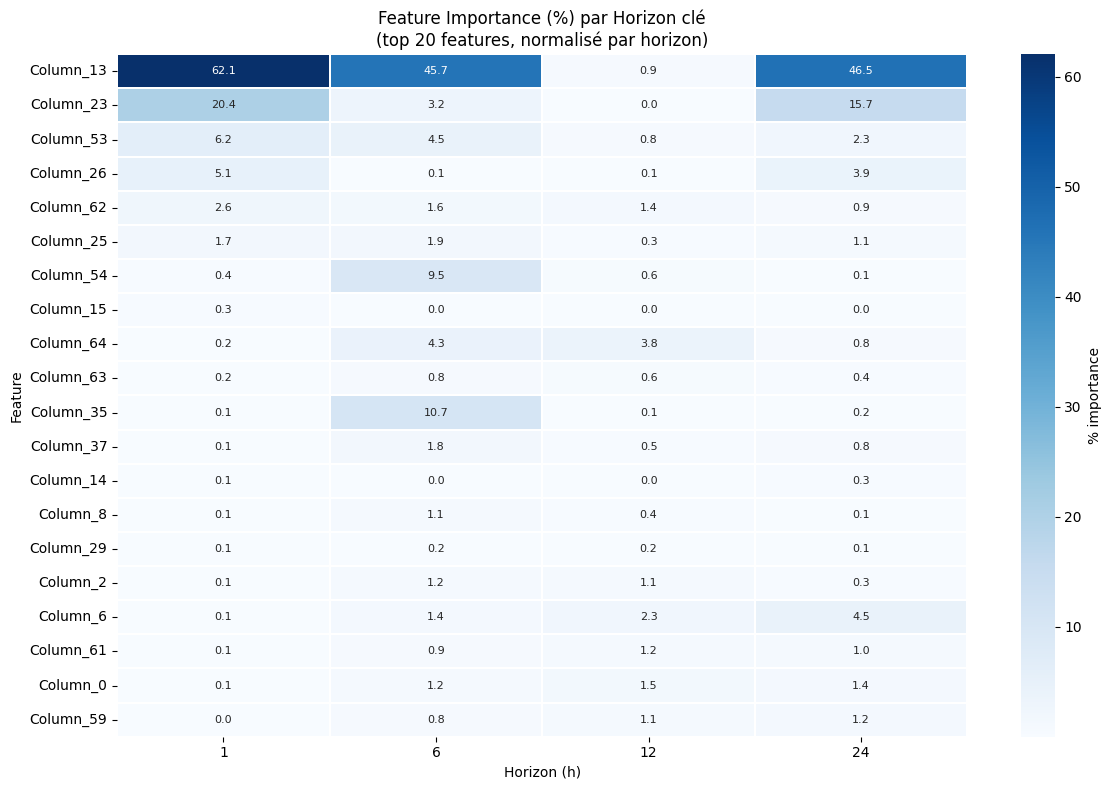

In [30]:
# ── Feature importance vs Horizon (LGB) ──────────────────────────────────────
key_h = [1, 6, 12, 24]
if all(h in models_lgb for h in key_h):
    fi_by_h = {}
    top_set  = set()
    for h in key_h:
        m  = models_lgb[h]
        fi = pd.Series(m.feature_importance('gain'), index=m.feature_name())
        fi_by_h[h] = fi
        top_set.update(fi.nlargest(15).index.tolist())

    df_fi = pd.DataFrame({h: fi_by_h[h] for h in key_h}).loc[list(top_set)]
    df_fi_norm = (df_fi.div(df_fi.sum(axis=0),axis=1)*100).sort_values(1,ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12,8))
    sns.heatmap(df_fi_norm.round(2), annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.3, ax=ax, cbar_kws={'label':'% importance'}, annot_kws={'size':8})
    ax.set(xlabel='Horizon (h)', ylabel='Feature',
           title='Feature Importance (%) par Horizon clé\n(top 20 features, normalisé par horizon)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig9_fi_by_horizon.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Modèles H+1/6/12/24 non disponibles → skip')


---
## 14. Figure 9 — Pics de Pollution (p50→p99)

,Seuil,Valeur (µg/m³),N,MAE – Blend,MAE – Persistence,% Erreur
0,p50,8.100000,66310,0.915000,1.727000,6.600000
1,p75,12.300000,33092,1.211000,2.257000,6.700000
2,p90,17.100000,13353,1.721000,3.161000,7.400000
3,p95,20.700000,6640,2.280000,4.102000,8.100000
4,p99,30.900000,1329,4.850000,7.674000,10.800000


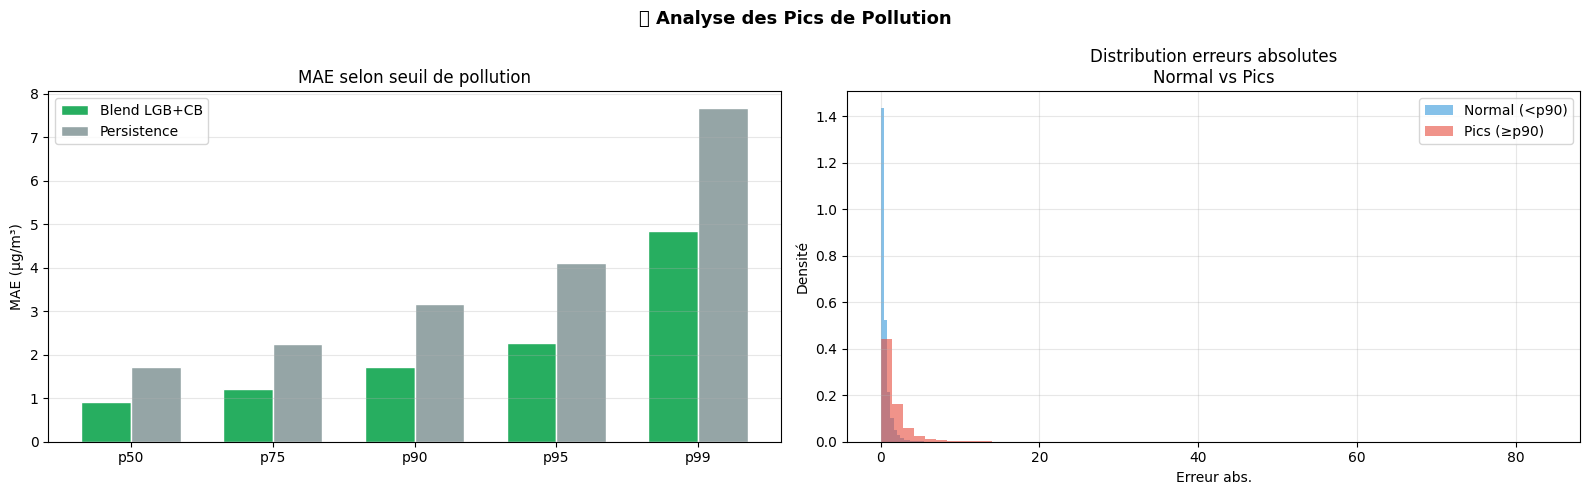

In [31]:
if 1 in models_lgb and 1 in models_cb:
    mh1  = df_test[TARGET_H1].notna().values
    yt_a = to_np(df_test.loc[mh1, TARGET_H1]).astype(float)
    yp_lgb_ = models_lgb[1].predict(X_te[mh1])
    pool_   = Pool(df_test.loc[mh1, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    yp_cb_  = models_cb[1].predict(pool_)
    yp_bl_  = blend_w[0]*yp_lgb_ + blend_w[1]*yp_cb_
    yp_pe_  = to_np(df_test.loc[mh1, 'pm25_lag_1h']).astype(float)

    thresholds = {f'p{p}': float(np.percentile(yt_a,p)) for p in [50,75,90,95,99]}
    peak_rows  = []
    for label, thresh in thresholds.items():
        mpeak = yt_a >= thresh
        if mpeak.sum() < 5: continue
        yt_p, yp_p, yp_pe = yt_a[mpeak], yp_bl_[mpeak], yp_pe_[mpeak]
        peak_rows.append({
            'Seuil': label, 'Valeur (µg/m³)': round(thresh,1),
            'N': int(mpeak.sum()),
            'MAE – Blend':       round(float(mean_absolute_error(yt_p,yp_p)),3),
            'MAE – Persistence': round(float(mean_absolute_error(yt_p,yp_pe)),3),
            '% Erreur':          round(float(mean_absolute_error(yt_p,yp_p)/yt_p.mean()*100),1),
        })
    df_peaks = pd.DataFrame(peak_rows)
    display(df_peaks.style.background_gradient(
        subset=['MAE – Blend','MAE – Persistence'], cmap='RdYlGn_r'))

    fig, axes = plt.subplots(1, 2, figsize=(16,5))
    x = np.arange(len(df_peaks)); w = 0.35
    axes[0].bar(x-w/2, df_peaks['MAE – Blend'],       w, color='#27AE60', label='Blend LGB+CB', edgecolor='white')
    axes[0].bar(x+w/2, df_peaks['MAE – Persistence'], w, color='#95A5A6', label='Persistence',  edgecolor='white')
    axes[0].set(title='MAE selon seuil de pollution',
                ylabel='MAE (µg/m³)', xticks=x, xticklabels=df_peaks['Seuil'])
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    err_n = np.abs(yt_a[yt_a <  thresholds['p90']] - yp_bl_[yt_a <  thresholds['p90']])
    err_p = np.abs(yt_a[yt_a >= thresholds['p90']] - yp_bl_[yt_a >= thresholds['p90']])
    axes[1].hist(err_n, bins=60, color='#3498DB', alpha=0.6, density=True, label='Normal (<p90)')
    axes[1].hist(err_p, bins=60, color='#E74C3C', alpha=0.6, density=True, label='Pics (≥p90)')
    axes[1].set(title='Distribution erreurs absolutes\nNormal vs Pics', xlabel='Erreur abs.', ylabel='Densité')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('🚨 Analyse des Pics de Pollution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig10_peak_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Modèles non disponibles → skip')


---
## 15. Figure 10 — Scatter H+1/H+6/H+12/H+24

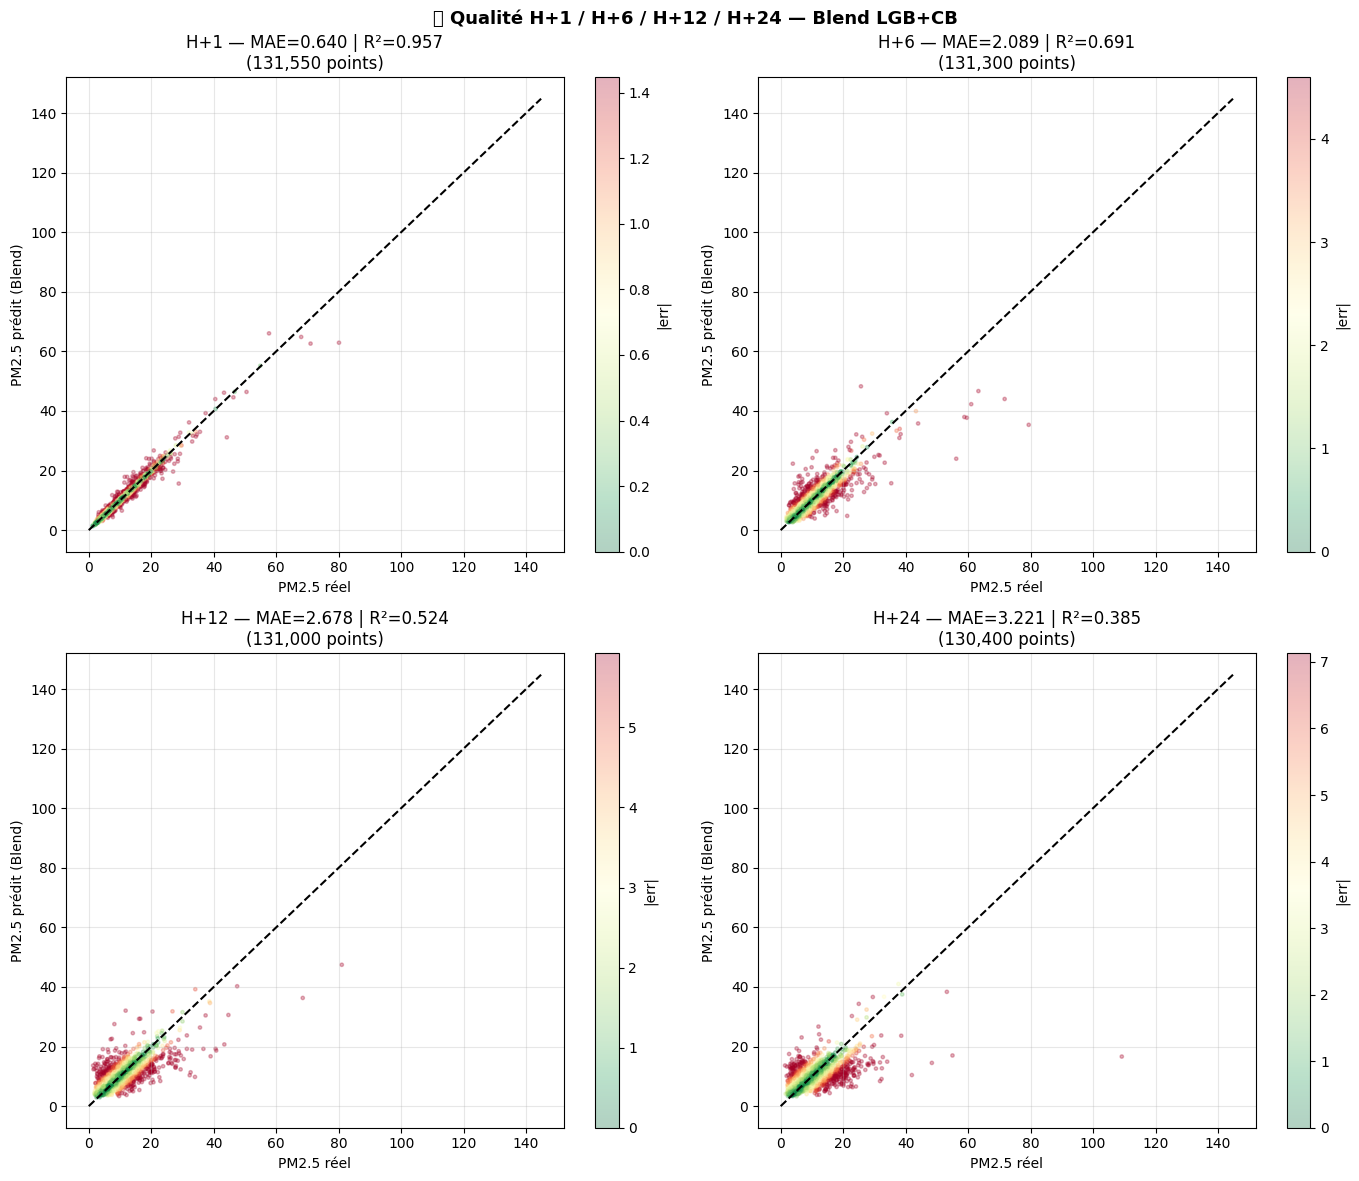

In [32]:
key_h4 = [1,6,12,24]
if all(h in models_lgb and h in models_cb for h in key_h4):
    fig, axes = plt.subplots(2,2, figsize=(14,12))
    axes = axes.flatten()
    for i,h in enumerate(key_h4):
        tc  = f'target24_h{h}'
        mte = df_test[tc].notna().values
        yt  = to_np(df_test.loc[mte, tc]).astype(float)
        yp_l = models_lgb[h].predict(X_te[mte])
        pool_h = Pool(df_test.loc[mte, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
        yp_c = models_cb[h].predict(pool_h)
        yp   = blend_w[0]*yp_l + blend_w[1]*yp_c
        mae_h = float(mean_absolute_error(yt,yp)); r2_h = float(r2_score(yt,yp))
        idx_s = np.random.choice(len(yt), min(2000,len(yt)), replace=False)
        lim   = float(max(yt.max(), yp.max()))
        sc    = axes[i].scatter(yt[idx_s], yp[idx_s], alpha=0.3, s=6,
                                c=np.abs(yt[idx_s]-yp[idx_s]), cmap='RdYlGn_r',
                                vmin=0, vmax=float(np.percentile(np.abs(yt-yp),90)))
        plt.colorbar(sc, ax=axes[i], label='|err|')
        axes[i].plot([0,lim],[0,lim],'k--',lw=1.5)
        axes[i].set(title=f'H+{h} — MAE={mae_h:.3f} | R²={r2_h:.3f}\n({len(yt):,} points)',
                    xlabel='PM2.5 réel', ylabel='PM2.5 prédit (Blend)')
        axes[i].grid(alpha=0.3)
    plt.suptitle('🎯 Qualité H+1 / H+6 / H+12 / H+24 — Blend LGB+CB', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig11_scatter_horizons.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Modèles H+1/6/12/24 non disponibles → skip')


---
## 16. Ranking Final & Dashboard Synthèse

In [33]:
# ── Tableau ranking final ─────────────────────────────────────────────────────
final_rows = []
for method in df_all_h['Method'].unique():
    sub = df_all_h[df_all_h['Method']==method].set_index('Horizon')
    row = {'Méthode': method,
           'Groupe': sub['Group'].iloc[0] if 'Group' in sub.columns else '',
           'MAE moyen': round(float(sub['MAE'].mean()),4)}
    for h in [1,6,12,24]:
        row[f'MAE H+{h}'] = round(float(sub.loc[h,'MAE']),3) if h in sub.index else np.nan
    final_rows.append(row)

df_ranking = pd.DataFrame(final_rows).sort_values('MAE moyen').reset_index(drop=True)
df_ranking.index += 1; df_ranking.index.name = 'Rang'

print('\n' + '═'*80)
print('  🏆  RANKING FINAL — TOUTES MÉTHODES & MODÈLES')
print('═'*80)
display(df_ranking.style.background_gradient(
    subset=['MAE moyen','MAE H+1','MAE H+6','MAE H+12','MAE H+24'], cmap='RdYlGn_r')
    .format({'MAE moyen':'{:.4f}','MAE H+1':'{:.3f}','MAE H+6':'{:.3f}',
             'MAE H+12':'{:.3f}','MAE H+24':'{:.3f}'}, na_rep='—'))
df_ranking.to_csv(OUT_DIR / 'FINAL_RANKING.csv', index=True)
print(f'\n✅ Ranking → {OUT_DIR}/FINAL_RANKING.csv')



════════════════════════════════════════════════════════════════════════════════
  🏆  RANKING FINAL — TOUTES MÉTHODES & MODÈLES
════════════════════════════════════════════════════════════════════════════════


,Méthode,Groupe,MAE moyen,MAE H+1,MAE H+6,MAE H+12,MAE H+24
Rang,,,,,,,
1,B2 – Moving Avg 6h,Baseline,1.9337,1.934,1.934,1.934,1.934
2,Blend Enrichi V2 (météo),NB6 – Météo,2.2416,0.638,1.960,2.424,2.789
3,Direct Blend,NB5 – Direct,2.4807,0.640,2.089,2.678,3.221
4,Blend LGB+CB (V1),NB4 – Ensemble,2.4807,0.640,2.089,2.678,3.221
5,CB Tuned,NB4 – Tuning,2.4938,0.644,2.105,2.701,3.224
6,LGB Tuned,NB4 – Tuning,2.5026,0.644,2.106,2.689,3.266
7,MIMO LGB,NB5 – MIMO,2.5372,0.644,2.101,2.723,3.357
8,B1 – Persistence,Baseline,3.1009,1.235,2.750,3.480,3.610
9,Hybrid Direct+Rec,NB5 – Hybrid,3.8921,0.640,2.941,4.432,4.847



✅ Ranking → E:\pipeline\test2\comparison_outputs/FINAL_RANKING.csv


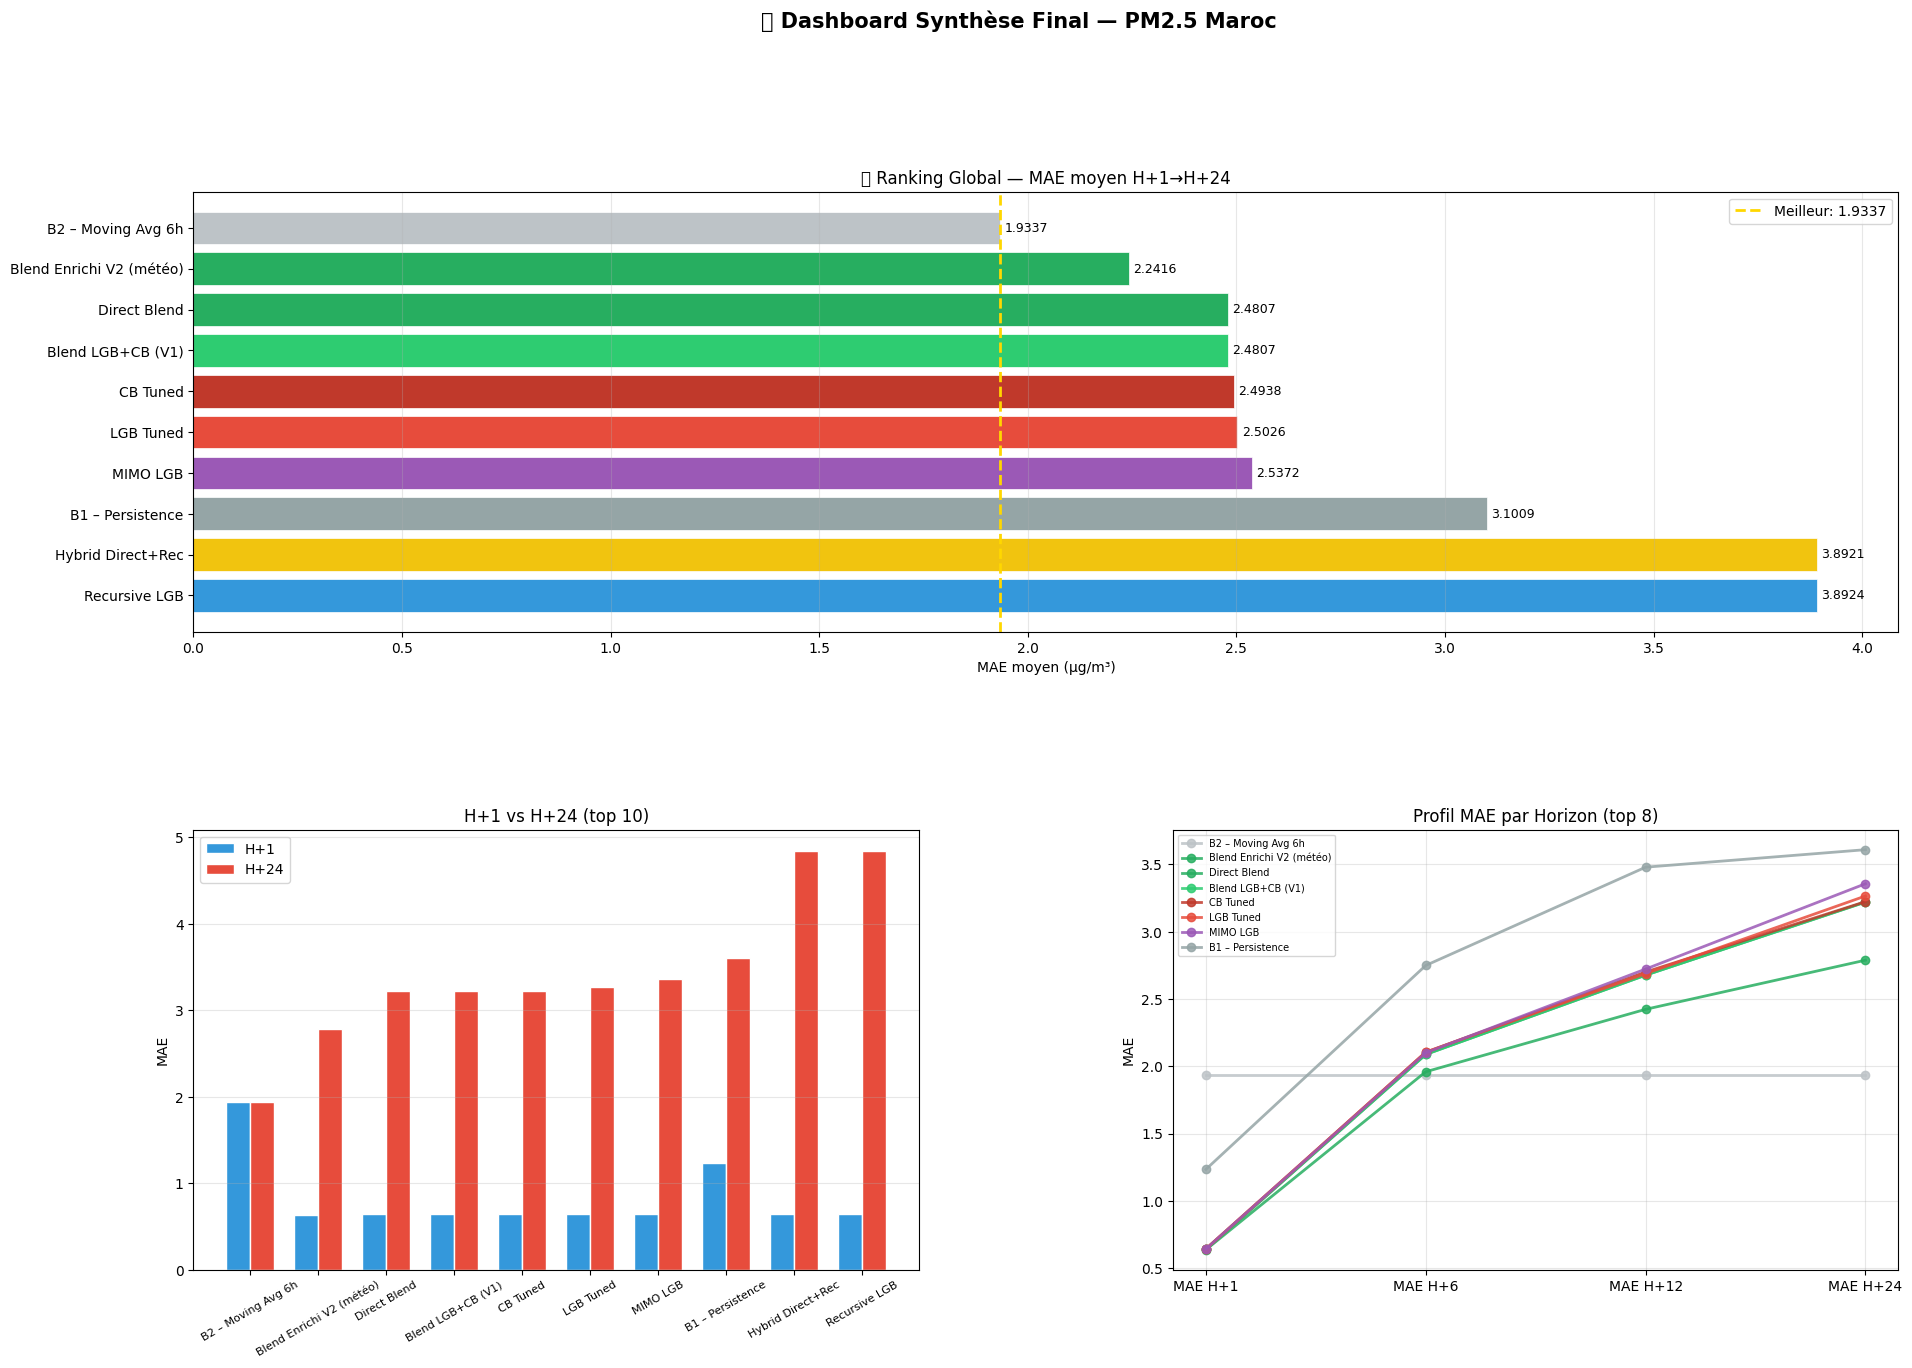

In [34]:
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])

# Ax0 : Barres ranking
colors_r = [get_color(m) for m in df_ranking['Méthode']]
bars_r = ax0.barh(df_ranking['Méthode'][::-1], df_ranking['MAE moyen'][::-1],
                  color=colors_r[::-1], edgecolor='white', lw=0.5)
ax0.bar_label(bars_r, fmt='%.4f', padding=3, fontsize=9)
ax0.axvline(df_ranking['MAE moyen'].min(), color='gold', lw=2, linestyle='--',
            label=f'Meilleur: {df_ranking["MAE moyen"].min():.4f}')
ax0.set(title='🏆 Ranking Global — MAE moyen H+1→H+24', xlabel='MAE moyen (µg/m³)')
ax0.legend(fontsize=10); ax0.grid(axis='x', alpha=0.3)

# Ax1 : H+1 vs H+24
df_r2 = df_ranking.dropna(subset=['MAE H+1','MAE H+24']).head(10)
xr = np.arange(len(df_r2)); wr = 0.35
ax1.bar(xr-wr/2, df_r2['MAE H+1'],  wr, color='#3498DB', label='H+1',  edgecolor='white')
ax1.bar(xr+wr/2, df_r2['MAE H+24'], wr, color='#E74C3C', label='H+24', edgecolor='white')
ax1.set(title='H+1 vs H+24 (top 10)', xticks=xr, xticklabels=df_r2['Méthode'], ylabel='MAE')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Ax2 : Parallel coordinates H+1/6/12/24
df_p = df_ranking.dropna(subset=['MAE H+1','MAE H+6','MAE H+12','MAE H+24']).head(8)
cols_p = ['MAE H+1','MAE H+6','MAE H+12','MAE H+24']
xp = np.arange(len(cols_p))
for _, row in df_p.iterrows():
    ax2.plot(xp, [row[c] for c in cols_p], 'o-', color=get_color(row['Méthode']),
             lw=2, label=row['Méthode'], ms=6, alpha=0.85)
ax2.set(title='Profil MAE par Horizon (top 8)', xticks=xp, xticklabels=cols_p, ylabel='MAE')
ax2.legend(fontsize=7, loc='upper left'); ax2.grid(alpha=0.3)

plt.suptitle('📊 Dashboard Synthèse Final — PM2.5 Maroc', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(OUT_DIR / 'fig12_dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# ── Résumé terminal ───────────────────────────────────────────────────────────
print('\n' + '═'*70)
print('  ✅  ANALYSE COMPARATIVE TERMINÉE')
print('═'*70)
print(f'\n📁 Figures → {OUT_DIR}')
for f in sorted(OUT_DIR.glob('fig*.png')):
    print(f'   {f.name}')

best = df_ranking.iloc[0]
print(f'\n🥇 Meilleure méthode : {best["Méthode"]}')
print(f'   MAE moyen H1–H24 : {best["MAE moyen"]:.4f} µg/m³')
for h in [1,6,12,24]:
    v = best.get(f'MAE H+{h}','—')
    print(f'   MAE H+{h:>2}        : {v}')

print('\n📋 Recommandations :')
print('  1. Production    → méthode avec MAE moyen minimal ci-dessus')
print('  2. Villes dures  → modèle spécifique (Guelmim, pics extrêmes)')
print('  3. Météo future  → intégrer API OWM → gain attendu H+6→H+24')
print('  4. Temps réel    → notebook 7 pour refresh lags PM2.5 automatique')



══════════════════════════════════════════════════════════════════════
  ✅  ANALYSE COMPARATIVE TERMINÉE
══════════════════════════════════════════════════════════════════════

📁 Figures → E:\pipeline\test2\comparison_outputs
   fig10_peak_analysis.png
   fig11_scatter_horizons.png
   fig12_dashboard_final.png
   fig1_global_h1.png
   fig1_global_h1_comparison.png
   fig2_mae_by_horizon.png
   fig3_heatmap_mae.png
   fig4_tuning_impact.png
   fig4_tuning_meteo.png
   fig5_strategies.png
   fig5_weather_impact.png
   fig6_mae_by_city.png
   fig7_temporal.png
   fig8_feature_importance.png
   fig9_fi_by_horizon.png

🥇 Meilleure méthode : B2 – Moving Avg 6h
   MAE moyen H1–H24 : 1.9337 µg/m³
   MAE H+ 1        : 1.934
   MAE H+ 6        : 1.934
   MAE H+12        : 1.934
   MAE H+24        : 1.934

📋 Recommandations :
  1. Production    → méthode avec MAE moyen minimal ci-dessus
  2. Villes dures  → modèle spécifique (Guelmim, pics extrêmes)
  3. Météo future  → intégrer API OWM → gain a